# Streaming Decoder Visualizations

This notebook visualizes results saved by `save_split_results()` / `load_split_results()`.

Each split is stored in two files:
- `{split}_metadata.parquet` — scalar + list columns (WER, glosses, predictions, segments)
- `{split}_arrays.npz` — per-frame logit arrays (logits, probs, labels, states)

**Cells are organized by visualization type:**
1. Imports & Constants
2. I/O Helpers
3. Color Palette Helpers
4. Plot 1 — Sequence Timeline
5. Plot 2 — Post-bag Confidence Heatmap
6. Plot 3 — WER Distribution
7. Plot 4 — Split Overview Grid
8. Plot 5 — Sign-level Confusion Matrix
9. Convenience — Batch Export All Sequences
10. Run Everything

---
## 1. Imports & Constants

In [1]:
from __future__ import annotations

import json
import os
from typing import Sequence

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Constants — must match the values used in the decoder
# ---------------------------------------------------------------------------

# Directory where the .parquet and .npz result files live
RESULTS_DIR = "./"

# Frames per second captured by the Leap Motion sensor
LEAP_FPS = 30

# Number of consecutive frames whose votes are majority-pooled before
# committing a label (the "bag" in bag-of-frames decoding)
BAG_SIZE = 5

# Minimum post-bag top-1 probability required to accept a sign prediction
CONFIDENCE_THRESHOLD = 0.35

# Minimum gap between the top-1 sign probability and the background probability;
# if the gap is smaller the frame is treated as background
SIGN_BG_MARGIN = 0.10

# Label string used for the background / no-sign class
BACKGROUND_LABEL = "background"  # change if your project uses a different name

---
## 2. I/O Helpers
Functions to load saved split results from disk and extract per-sequence arrays.

In [2]:
def load_split_results(
    split_name: str,
    results_dir: str = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Reads two files written by save_split_results():
        {slug}_metadata.parquet  — WER scalars, GT glosses, predictions,
                                   emit_regions and gt_segments (as JSON strings)
        {slug}_arrays.npz        — per-frame logit/prob/label/state arrays

    Parameters
    ----------
    split_name  : e.g. "test", "dev_val", "test_(user1)" — must match
                  the slug used when saving
    results_dir : directory containing the parquet / npz files

    Returns
    -------
    df     : DataFrame with all scalars + list columns
    arrays : dict keyed by "{row_idx}__{rec_id}__{field}"
    """
    slug = (
        split_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    parquet_path = os.path.join(results_dir, f"{slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    def _deserialize_regions(x) -> list[tuple]:
        if not isinstance(x, str):
            return []
        out = []
        for r in json.loads(x):
            if isinstance(r, dict):
                # gt_segments saved as dicts — extract values by key
                out.append((int(r["start_frame"]), int(r["end_frame"]), str(r["label"])))
            elif isinstance(r, (list, tuple)) and len(r) >= 3:
                # emit_regions saved as lists — cast directly
                out.append((int(r[0]), int(r[1]), str(r[2])))
        return out

    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(_deserialize_regions)

    npz    = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(row: pd.Series, arrays: dict) -> dict:
    """
    Extract all per-frame arrays for a single DataFrame row.

    Constructs the key prefix from the row index and recording_id,
    then pulls every stored field from the shared arrays dict.

    Returns
    -------
    dict with keys:
        pre_bag_logits  (T, C) float32  — raw model logits before bag pooling
        post_bag_probs  (T, C) float32  — softmax probs after bag; first
                                          (BAG_SIZE-1) rows are NaN
        frame_indices   (T,)   int32    — original frame numbers
        raw_labels      (T,)   object   — per-frame pre-bag top-1 label string
        voted_labels    (T,)   object   — post-bag majority-vote label string
        raw_conf        (T,)   float32  — pre-bag top-1 confidence
        bg_conf         (T,)   float32  — post-bag background class confidence
        states          (T,)   object   — decoder FSM state string per frame
    """
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {f: arrays.get(f"{prefix}__{f}") for f in fields}


def _safe_segment_tuple(seg):
    """Convert a segment tuple/list/dict to (int start, int end, str label).
    Returns None if the input cannot be safely cast."""
    if isinstance(seg, dict):
        try:
            return (int(seg["start_frame"]), int(seg["end_frame"]), str(seg["label"]))
        except (KeyError, ValueError, TypeError):
            return None
    if isinstance(seg, (tuple, list)) and len(seg) >= 3:
        try:
            return (int(seg[0]), int(seg[1]), str(seg[2]))
        except (ValueError, TypeError):
            pass
    return None

---
## 3. Color Palette Helpers
Builds a stable color mapping from label strings to RGBA tuples. Background is always light grey; sign labels get distinct colors from the tab20 colormap.

In [3]:
def _build_label_colors(
    all_labels: Sequence[str],
    background_label: str = BACKGROUND_LABEL,
    cmap_name: str = "tab20",
) -> dict[str, tuple]:
    """
    Assign a stable, distinct color to every label.

    - Background label is always rendered as light grey so it never
      visually competes with actual sign labels.
    - Sign labels are sorted alphabetically before colors are assigned
      so the mapping is reproducible across calls with different label
      subsets (as long as the full vocabulary is the same).

    Parameters
    ----------
    all_labels       : full set of label strings seen in this context
    background_label : the label name to paint grey
    cmap_name        : matplotlib colormap to sample sign colors from

    Returns
    -------
    dict mapping label string → RGBA tuple
    """
    sign_labels = sorted(set(all_labels) - {background_label})

    # Support both old (get_cmap) and new (colormaps[]) matplotlib APIs
    try:
        cmap = plt.colormaps[cmap_name]
    except AttributeError:
        cmap = plt.cm.get_cmap(cmap_name)

    colors = [cmap(i) for i in range(len(sign_labels))] if sign_labels else []
    color_dict = {lbl: colors[i] for i, lbl in enumerate(sign_labels)}
    color_dict[background_label] = (0.88, 0.88, 0.88, 1.0)  # light grey
    return color_dict

---
## 4. Plot 1 — Sequence Timeline

**What it shows:** A three-row timeline for a single recording.

| Row | Content |
|-----|---------|
| 0 — GT regions | Colored bars spanning the ground-truth segment boundaries, labeled with the gloss |
| 1 — Pre-bag vote | Frame-by-frame color strip of the decoder's top-1 label *before* bag pooling; red dashed lines mark emission events |
| 2 — Confidence curves | Pre-bag and post-bag top-1 confidence over time, background confidence, threshold lines, and blue shading where the FSM is in the IN_SIGN state |

**Use it to:** spot where the model is uncertain, where it transitions correctly vs incorrectly, and how the bag smoothing changes confidence.

In [ ]:
# def plot_sequence_timeline(
#     row: pd.Series,
#     arrays: dict,
#     label_colors: dict | None = None,
#     background_label: str     = BACKGROUND_LABEL,
#     figsize: tuple            = (20, 7),
#     title: str | None         = None,
#     save_path: str | None     = None,
# ) -> plt.Figure:
#     """
#     Three-row timeline for one sequence.

#     Row 0 — Ground-truth segmentation regions (colored bars)
#     Row 1 — Per-frame decoder voted label (pre-bag top-1, colored by label).
#              Red dashed vertical lines mark emission events.
#     Row 2 — Confidence curves:
#              pre-bag top-1 conf  (blue)
#              post-bag top-1 conf (green)
#              background conf     (grey dashed)
#              CONFIDENCE_THRESHOLD (red dotted)
#              SIGN_BG_MARGIN       (orange dotted)
#              Blue shading = frames where the FSM is in the IN_SIGN state.

#     Parameters
#     ----------
#     row          : one row from a split DataFrame
#     arrays       : arrays dict from load_split_results()
#     label_colors : optional pre-built color dict (share across calls for
#                    consistent coloring across sequences)
#     save_path    : if given, saves figure here instead of displaying inline
#     """
#     seq        = get_sequence_arrays(row, arrays)
#     frames     = seq["frame_indices"]
#     raw_labels = seq["raw_labels"]        # pre-bag top-1 label per frame
#     raw_conf   = seq["raw_conf"]          # pre-bag top-1 confidence
#     bg_conf    = seq["bg_conf"]           # post-bag background confidence

#     # Post-bag top-1 confidence — NaN for the first (BAG_SIZE-1) frames
#     post_bag = seq["post_bag_probs"]      # (T, C)
#     if post_bag is not None:
#         with np.errstate(invalid="ignore"):
#             post_conf = np.nanmax(post_bag, axis=1)   # collapse classes → (T,)
#     else:
#         post_conf = np.full_like(raw_conf, np.nan)

#     T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
#     gt_segments  = row.get("gt_segments",  [])
#     emit_regions = row.get("emit_regions", [])

#     # Ensure every segment is a valid (int, int, str) tuple
#     gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
#     emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

#     # Build a color palette that covers every label appearing in this sequence
#     all_labels  = set(raw_labels.tolist()) if raw_labels is not None else set()
#     all_labels |= {seg[2] for seg in gt_segments}
#     all_labels |= {r[2]   for r in emit_regions}
#     all_labels.add(background_label)

#     if label_colors is None:
#         label_colors = _build_label_colors(all_labels, background_label)

#     # ------------------------------------------------------------------
#     # Figure layout: 3 rows with height ratio 1 : 1 : 2.5
#     # ------------------------------------------------------------------
#     fig = plt.figure(figsize=figsize, constrained_layout=True)
#     gs  = gridspec.GridSpec(
#         3, 1, figure=fig,
#         height_ratios=[1, 1, 2.5],
#         hspace=0.08,
#     )
#     ax0 = fig.add_subplot(gs[0])   # ground-truth regions
#     ax1 = fig.add_subplot(gs[1])   # per-frame voted label strip
#     ax2 = fig.add_subplot(gs[2])   # confidence curves

#     # ---- Row 0: GT segmentation regions --------------------------------
#     if gt_segments:
#         for (start, end, label) in gt_segments:
#             color = label_colors.get(label, "steelblue")
#             ax0.barh(
#                 0, end - start, left=start, height=0.6,
#                 color=color, edgecolor="black", linewidth=0.5,
#             )
#             # Label text — white on dark backgrounds, black on light ones
#             cx = (start + end) / 2
#             ax0.text(
#                 cx, 0, label,
#                 ha="center", va="center", fontsize=7, fontweight="bold",
#                 color="white" if sum(color[:3]) < 1.5 else "black",
#                 clip_on=True,
#             )
#     else:
#         ax0.text(0.5, 0.5, "No GT segments available",
#                  ha="center", va="center", transform=ax0.transAxes, fontsize=9)

#     ax0.set_yticks([0])
#     ax0.set_yticklabels(["GT"], fontsize=9)
#     ax0.set_xlim(0, T)
#     ax0.set_ylim(-0.5, 0.5)
#     ax0.tick_params(bottom=False, labelbottom=False)
#     ax0.set_title(
#         title or (
#             f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
#             f"WER={float(row['wer']):.3f}  "
#             f"GT: {row.get('ground_truth', '')}  "
#             f"Pred: {row.get('prediction', '')}"
#         ),
#         fontsize=10, loc="left",
#     )

#     # ---- Row 1: per-frame pre-bag voted label --------------------------
#     if raw_labels is not None and len(raw_labels) == len(frames):
#         for i, fi in enumerate(frames):
#             label = str(raw_labels[i])
#             color = label_colors.get(label, "lightgrey")
#             ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

#     # Red dashed verticals + rotated label text at each emission midpoint
#     for (start, end, label) in emit_regions:
#         mid = (start + end) / 2
#         ax1.axvline(mid, color="red", linewidth=1.5, linestyle="--", alpha=0.85)
#         ax1.text(
#             mid, 0.45, label,
#             ha="center", va="top", fontsize=6.5, color="red",
#             rotation=90, clip_on=True,
#         )

#     ax1.set_yticks([0])
#     ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
#     ax1.set_xlim(0, T)
#     ax1.set_ylim(-0.5, 0.5)
#     ax1.tick_params(bottom=False, labelbottom=False)

#     # ---- Row 2: confidence curves -------------------------------------
#     ax2.plot(frames, raw_conf,  color="steelblue", linewidth=1.2,
#              label="Pre-bag top-1 conf",  zorder=3)
#     ax2.plot(frames, post_conf, color="seagreen",  linewidth=1.2,
#              label="Post-bag top-1 conf", zorder=3)
#     ax2.plot(frames, bg_conf,   color="grey",      linewidth=1.0,
#              linestyle="--", alpha=0.7, label="Post-bag BG conf", zorder=2)

#     # Threshold reference lines
#     ax2.axhline(CONFIDENCE_THRESHOLD, color="red",        linewidth=1.0,
#                 linestyle=":", label=f"Conf threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
#     ax2.axhline(SIGN_BG_MARGIN,       color="darkorange", linewidth=1.0,
#                 linestyle=":", label=f"BG margin ({SIGN_BG_MARGIN})",           zorder=1)

#     # Blue shading wherever the decoder FSM is in the IN_SIGN state
#     states = seq["states"]
#     if states is not None and len(states) == len(frames):
#         in_sign    = False
#         sign_start = None
#         for i, fi in enumerate(frames):
#             st = str(states[i])
#             if st == "IN_SIGN" and not in_sign:
#                 in_sign    = True
#                 sign_start = fi
#             elif st != "IN_SIGN" and in_sign:
#                 ax2.axvspan(sign_start, fi, alpha=0.08, color="steelblue", zorder=0)
#                 in_sign = False
#         if in_sign:   # close any open region at the end of the sequence
#             ax2.axvspan(sign_start, frames[-1], alpha=0.08, color="steelblue", zorder=0)

#     # Emission markers echoed on the confidence plot for cross-referencing
#     for (start, end, label) in emit_regions:
#         ax2.axvline((start + end) / 2, color="red",
#                     linewidth=1.2, linestyle="--", alpha=0.7)

#     ax2.set_ylim(0, 1.05)
#     ax2.set_xlim(0, T)
#     ax2.set_xlabel("Frame index", fontsize=9)
#     ax2.set_ylabel("Confidence",  fontsize=9)
#     ax2.legend(fontsize=8, loc="upper right", ncol=3)
#     ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.2))

#     # Shared legend for label colors + emission marker
#     handles = [
#         mpatches.Patch(color=c, label=l)
#         for l, c in label_colors.items() if l != background_label
#     ]
#     handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
#     handles.append(Line2D([0], [0], color="red", linestyle="--",
#                           linewidth=1.5, label="Emission"))
#     fig.legend(
#         handles=handles, loc="lower center", fontsize=7,
#         ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
#     )

#     if save_path:
#         fig.savefig(save_path, bbox_inches="tight", dpi=150)
#         print(f"Saved → {save_path}")
#     else:
#         plt.show()

#     return fig

In [4]:
def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    label_colors: dict | None = None,
    background_label: str     = BACKGROUND_LABEL,
    figsize: tuple            = (20, 10),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    Five-row timeline for one sequence.

    Row 0 — Ground-truth segmentation regions (colored bars)
    Row 1 — Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 2 — Per-frame post-bag voted label strip (smoothed)
    Row 3 — Pre-bag top-1 probability curve (after softmax)
    Row 4 — Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end, labelled on row 1.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax → top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 5 rows — height ratios 1 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        5, 1, figure=fig,
        height_ratios=[1, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])
    ax3 = fig.add_subplot(gs[3])
    ax4 = fig.add_subplot(gs[4])

    all_axes = [ax0, ax1, ax2, ax3, ax4]

    # Shared x-tick helper — every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper — draw emit regions across a given set of axes
    # Shaded span + dotted start/end lines + label text on ax1 only
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 2: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 3: pre-bag top-1 probability ------------------------------
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 4: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    # Label text placed on ax1 (pre-bag strip) where there's vertical room
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Emit region legend entries
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 5. Plot 2 — Post-bag Confidence Heatmap

**What it shows:** A Class × Frame heatmap of post-bag softmax probabilities for one recording. Brighter cells = higher probability that class was active at that frame.

- **White vertical lines** — ground-truth segment boundaries
- **Cyan dashed lines** — emission events
- **Dashed horizontal line** — separates sign classes from the background class

**Use it to:** understand which classes the model confused, how sharply probability peaks at the correct sign, and whether the model was uncertain between two similar signs.

In [5]:
def plot_confidence_heatmap(
    row: pd.Series,
    arrays: dict,
    id_to_label: dict[int, str],
    background_label: str = BACKGROUND_LABEL,
    figsize: tuple        = (20, 6),
    title: str | None     = None,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Class × Frame heatmap of post-bag probabilities.

    Reveals which classes the model was uncertain between over time.
    GT segment boundaries and emission region markers are overlaid.

    Layout
    ------
    Top row  — GT segmentation bar (same as timeline Row 0)
    Main     — YlOrRd heatmap: rows = classes (signs alphabetically,
               background last), columns = frames

    Parameters
    ----------
    id_to_label : {class_index: label_string} — same mapping used during
                  training / inference to build the output layer
    save_path   : if given, saves figure here instead of displaying inline
    """
    seq      = get_sequence_arrays(row, arrays)
    frames   = seq["frame_indices"]
    post_bag = seq["post_bag_probs"]    # (T, C)

    if post_bag is None or np.all(np.isnan(post_bag)):
        print(f"No post-bag probs available for {row.get('recording_id', '?')}")
        return None

    T, C       = post_bag.shape
    label_list = [id_to_label.get(i, f"cls_{i}") for i in range(C)]

    # Reorder rows: sign classes alphabetically, background at the bottom
    sign_idxs = sorted(
        [i for i, l in enumerate(label_list) if l != background_label],
        key=lambda i: label_list[i],
    )
    bg_idxs       = [i for i, l in enumerate(label_list) if l == background_label]
    row_order      = sign_idxs + bg_idxs
    ordered_labels = [label_list[i] for i in row_order]
    ordered_probs  = post_bag[:, row_order].T    # (C, T) for imshow

    gt_segments  = [_safe_segment_tuple(s) for s in row.get("gt_segments",  []) if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in row.get("emit_regions", []) if _safe_segment_tuple(r)]

    fig, axes = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={"height_ratios": [1, 6]},
        constrained_layout=True,
    )
    ax_gt = axes[0]
    ax_hm = axes[1]

    # ---- GT bar --------------------------------------------------------
    all_gt_labels = {seg[2] for seg in gt_segments} | {background_label}
    label_colors  = _build_label_colors(all_gt_labels, background_label)

    for (start, end, label) in gt_segments:
        ax_gt.barh(
            0, end - start, left=start, height=0.6,
            color=label_colors.get(label, "steelblue"),
            edgecolor="black", linewidth=0.4,
        )
        ax_gt.text((start + end) / 2, 0, label,
                   ha="center", va="center", fontsize=7, fontweight="bold")

    ax_gt.set_xlim(frames[0], frames[-1] + 1)
    ax_gt.set_ylim(-0.5, 0.5)
    ax_gt.set_yticks([0])
    ax_gt.set_yticklabels(["GT"], fontsize=8)
    ax_gt.tick_params(bottom=False, labelbottom=False)
    ax_gt.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Probability heatmap ------------------------------------------
    im = ax_hm.imshow(
        ordered_probs,
        aspect="auto",
        origin="lower",
        cmap="YlOrRd",
        vmin=0, vmax=1,
        extent=[frames[0], frames[-1] + 1, -0.5, C - 0.5],
        interpolation="nearest",
    )

    # GT boundaries as white verticals
    for (start, end, _) in gt_segments:
        ax_hm.axvline(start, color="white", linewidth=1.2, alpha=0.9)
        ax_hm.axvline(end,   color="white", linewidth=1.2, alpha=0.9)

    # Emission events as cyan dashed verticals
    for (start, end, label) in emit_regions:
        ax_hm.axvline((start + end) / 2, color="cyan",
                      linewidth=1.5, linestyle="--", alpha=0.9)

    ax_hm.set_yticks(range(C))
    ax_hm.set_yticklabels(ordered_labels, fontsize=7)
    ax_hm.set_xlabel("Frame index", fontsize=9)

    # Dashed line separating sign rows from the background row
    n_sign = len(sign_idxs)
    ax_hm.axhline(n_sign - 0.5, color="white", linewidth=1.5, linestyle="--")

    plt.colorbar(im, ax=ax_hm, label="Post-bag probability",
                 fraction=0.015, pad=0.01)

    ax_hm.legend(
        handles=[
            Line2D([0], [0], color="white", linewidth=1.2, label="GT boundary"),
            Line2D([0], [0], color="cyan",  linewidth=1.5, linestyle="--", label="Emission"),
        ],
        fontsize=8, loc="upper right",
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 6. Plot 3 — WER Distribution

**What it shows:** A two-panel summary of Word Error Rate across a whole split.

| Panel | Content |
|-------|---------|
| Left — Histogram | Distribution of WER values; mean (red) and median (orange) dashed lines; std annotated |
| Right — Box plot | Per-user WER spread (or per-sequence scatter if only one user) |

**Use it to:** quickly identify whether errors are concentrated in specific users or spread uniformly, and benchmark overall decoder quality.

In [4]:
def plot_wer_distribution(
    df: pd.DataFrame,
    split_name: str       = "",
    figsize: tuple        = (14, 5),
    top_n_worst: int      = 10,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Two-panel WER distribution plot for an entire split.

    Left  — Histogram of WER values with mean / median reference lines
             and sample-count + std annotation.
    Right — Per-user box plot (one box per unique user).
             If only one user is present, falls back to a per-sequence
             scatter plot so the panel is never empty.

    Also prints the top_n_worst sequences ranked by WER (descending).

    Parameters
    ----------
    df          : DataFrame returned by load_split_results()
    split_name  : shown in the figure suptitle
    top_n_worst : how many worst-WER sequences to print (default 10)
    save_path   : if given, saves figure here instead of displaying inline

    Note on double-display
    ----------------------
    plt.show() is intentionally NOT called here. Jupyter auto-renders the
    returned Figure object, so calling plt.show() would cause it to appear
    twice. When save_path is set, plt.close() is called to free memory.
    """
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(f"WER Distribution — {split_name}", fontsize=12)

    wer = df["wer"].dropna().values

    # ---- Left: WER histogram ------------------------------------------
    ax_hist.hist(wer, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax_hist.axvline(wer.mean(),     color="red",    linewidth=1.5, linestyle="--",
                    label=f"Mean   {wer.mean():.3f}")
    ax_hist.axvline(np.median(wer), color="orange", linewidth=1.5, linestyle="--",
                    label=f"Median {np.median(wer):.3f}")
    ax_hist.set_xlabel("WER",   fontsize=9)
    ax_hist.set_ylabel("Count", fontsize=9)
    ax_hist.set_title("WER histogram", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.set_xlim(0, max(1.0, wer.max() + 0.05))
    # Std + sample count in the top-right corner
    ax_hist.text(
        0.98, 0.97, f"n={len(wer)}\nstd={wer.std():.3f}",
        ha="right", va="top", transform=ax_hist.transAxes,
        fontsize=8, color="grey",
    )

    # ---- Right: per-user box plot (or scatter for single-user splits) --
    if "user" in df.columns and df["user"].nunique() > 1:
        users     = sorted(df["user"].unique())
        user_wers = [df.loc[df["user"] == u, "wer"].values for u in users]
        bp = ax_box.boxplot(
            user_wers, labels=users, patch_artist=True,
            medianprops=dict(color="red", linewidth=1.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor("steelblue")
            patch.set_alpha(0.5)
        ax_box.set_xlabel("User", fontsize=9)
        ax_box.set_ylabel("WER",  fontsize=9)
        ax_box.set_title("WER by user", fontsize=10)
        ax_box.tick_params(axis="x", rotation=30)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))
    else:
        # Single user: show per-sequence scatter instead
        ax_box.scatter(df["sample_idx"], df["wer"],
                       color="steelblue", s=25, alpha=0.7)
        ax_box.set_xlabel("Sequence index", fontsize=9)
        ax_box.set_ylabel("WER",            fontsize=9)
        ax_box.set_title("WER per sequence", fontsize=10)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))

    # ---- Print top-N worst sequences ----------------------------------
    # Sort by WER descending; ties keep their original DataFrame order.
    # Prints: rank, recording_id, WER, user (if present), GT, prediction.
    n_to_show = min(top_n_worst, len(df))
    worst     = df.nlargest(n_to_show, "wer")

    print(f"\n{'='*60}")
    print(f"  Top {n_to_show} worst sequences — {split_name}")
    print(f"{'='*60}")
    for rank, (_, row) in enumerate(worst.iterrows(), start=1):
        rec_id  = row.get("recording_id", "—")
        wer_val = float(row["wer"])
        gt      = row.get("ground_truth", "—")
        pred    = row.get("prediction",   "—")
        user    = f"  user={row['user']}" if "user" in row and pd.notna(row["user"]) else ""
        print(f"  #{rank:<3} WER={wer_val:.3f}{user}")
        print(f"       id  : {rec_id}")
        print(f"       GT  : {gt}")
        print(f"       pred: {pred}")
        print()
    print(f"{'='*60}\n")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
        plt.close(fig)  # free memory; no inline display needed when saving

    # No plt.show() — Jupyter renders the returned Figure automatically.
    # Calling plt.show() here would cause the plot to appear twice.
    return fig

---
## 7. Plot 4 — Split Overview Grid

**What it shows:** A compact grid of mini-timelines — one row per sequence, two columns (GT | decoder vote). WER is color-coded green (0) or red (> 0).

**Use it to:** get a bird's-eye view of an entire split at once — quickly spot which sequences are clean, which have systematic errors, and whether errors cluster by user or sign type.

In [7]:
def plot_split_overview(
    df: pd.DataFrame,
    arrays: dict,
    background_label: str = BACKGROUND_LABEL,
    max_sequences: int    = 30,
    figsize: tuple        = (22, None),  # height auto-computed from n sequences
    save_path: str | None = None,
) -> plt.Figure:
    """
    Grid of mini-timelines for all (up to max_sequences) sequences in a split.

    Each grid row contains two panels:
        Left  — GT segmentation (color-coded by label)
        Right — Pre-bag per-frame decoder vote with emission markers

    WER label on the left edge: green = perfect (0.0), red = error (> 0).

    Parameters
    ----------
    max_sequences : cap on rows to keep the figure readable
    figsize       : (width, height); height is auto-computed if None
    save_path     : if given, saves figure here instead of displaying inline
    """
    rows_to_show = df.head(max_sequences)
    n            = len(rows_to_show)

    if n == 0:
        print("DataFrame is empty — nothing to plot.")
        return None

    # Build a shared color palette across all sequences for consistency
    all_labels = set()
    for _, row in rows_to_show.iterrows():
        seq = get_sequence_arrays(row, arrays)
        if seq["raw_labels"] is not None:
            all_labels.update(seq["raw_labels"].tolist())
        for seg in row.get("gt_segments", []):
            t = _safe_segment_tuple(seg)
            if t:
                all_labels.add(t[2])
    all_labels.add(background_label)
    label_colors = _build_label_colors(all_labels, background_label)

    # Auto-compute figure height based on sequence count
    row_height  = 0.55
    fig_height  = figsize[1] if figsize[1] else max(6, n * row_height * 2 + 2)
    fig, axes   = plt.subplots(
        n, 2, figsize=(figsize[0], fig_height),
        gridspec_kw={"width_ratios": [1, 1], "wspace": 0.02, "hspace": 0.05},
        squeeze=False,
    )
    fig.suptitle(
        f"Split overview — {len(rows_to_show)} sequences  "
        f"(mean WER={df['wer'].mean():.3f})",
        fontsize=11,
    )

    for plot_idx, (_, row) in enumerate(rows_to_show.iterrows()):
        ax_gt   = axes[plot_idx][0]
        ax_pred = axes[plot_idx][1]

        seq    = get_sequence_arrays(row, arrays)
        frames = seq["frame_indices"]
        T      = (frames[-1] + 1) if frames is not None and len(frames) > 0 else 1

        # Color the WER label green for perfect sequences, red otherwise
        wer_color = "green" if float(row["wer"]) == 0.0 else "red"

        # GT segments
        gt_segs = [_safe_segment_tuple(s) for s in row.get("gt_segments", []) if _safe_segment_tuple(s)]
        for (start, end, label) in gt_segs:
            ax_gt.barh(0, end - start, left=start, height=0.6,
                       color=label_colors.get(label, "steelblue"), edgecolor="none")

        ax_gt.set_xlim(0, T)
        ax_gt.set_ylim(-0.5, 0.5)
        ax_gt.axis("off")
        ax_gt.set_ylabel(f"{row.get('recording_id', '')[:18]}",
                         fontsize=6, rotation=0, ha="right", va="center")
        ax_gt.text(-0.01, 0.5, f"WER={float(row['wer']):.2f}",
                   transform=ax_gt.transAxes, fontsize=6,
                   ha="right", va="center", color=wer_color)

        # Per-frame pre-bag decoder vote
        if seq["raw_labels"] is not None and len(seq["raw_labels"]) == len(frames):
            for i, fi in enumerate(frames):
                label = str(seq["raw_labels"][i])
                ax_pred.barh(0, 1, left=fi, height=0.6,
                             color=label_colors.get(label, "lightgrey"), edgecolor="none")

        # Emission markers
        emit_regs = [_safe_segment_tuple(r) for r in row.get("emit_regions", []) if _safe_segment_tuple(r)]
        for (start, end, _) in emit_regs:
            ax_pred.axvline((start + end) / 2, color="red",
                            linewidth=0.8, linestyle="--", alpha=0.8)

        ax_pred.set_xlim(0, T)
        ax_pred.set_ylim(-0.5, 0.5)
        ax_pred.axis("off")

    # Column headers on the first row only
    axes[0][0].set_title("Ground truth",       fontsize=9)
    axes[0][1].set_title("Pre-bag decoder vote", fontsize=9)

    # Shared legend for label colors
    handles = [mpatches.Patch(color=c, label=l) for l, c in label_colors.items()]
    fig.legend(
        handles=handles, loc="lower center",
        ncol=min(len(handles), 10), fontsize=6,
        bbox_to_anchor=(0.5, -0.01),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=130)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 8. Plot 5 — Sign-level Confusion Matrix

**What it shows:** A matrix of GT signs (rows) vs predicted signs (cols), built by aligning `emit_regions` with `gt_segments`.

**Alignment strategy:**
- For each GT segment, find the emission whose midpoint falls inside it → that's the prediction.
- Unmatched GT segments → **deletions** (reported in title)
- Unmatched emissions → **insertions** (reported in title)

**Use it to:** identify which pairs of signs are systematically confused, and quantify deletion vs insertion error modes.

In [5]:
def plot_confusion_from_emissions(
    df: pd.DataFrame,
    background_label: str = BACKGROUND_LABEL,
    figsize: tuple        = (12, 10),
    normalize: bool       = True,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Sign-level confusion matrix built by aligning emit_regions with gt_segments.

    Alignment: for each GT segment, the emitted sign whose region midpoint
    falls inside the GT segment is treated as the prediction.
    Unmatched GT segments  → deletion  (tallied; shown in the title)
    Unmatched emissions    → insertion (tallied; shown in the title)

    Parameters
    ----------
    normalize : if True, each row is divided by (row_hits + row_deletions)
                so cells show per-class recall (row sums ≤ 1).
                if False, raw counts are shown.
    save_path : if given, saves figure here instead of displaying inline
    """
    # Gather every sign label that appears in predictions or GT
    all_signs = set()
    for _, row in df.iterrows():
        for seg in row.get("gt_segments", []):
            t = _safe_segment_tuple(seg)
            if t and t[2] != background_label:
                all_signs.add(t[2])
        for reg in row.get("emit_regions", []):
            t = _safe_segment_tuple(reg)
            if t and t[2] != background_label:
                all_signs.add(t[2])

    labels     = sorted(all_signs)
    label_to_i = {l: i for i, l in enumerate(labels)}
    n          = len(labels)

    if n == 0:
        print("No sign labels found in emit_regions / gt_segments.")
        return None

    # Accumulate hits, deletions, and insertions across all sequences
    conf_matrix = np.zeros((n, n), dtype=np.float32)   # [gt_i, pred_i]
    deletions   = np.zeros(n, dtype=np.float32)         # gt sign not emitted
    insertions  = 0                                     # emission with no GT match

    for _, row in df.iterrows():
        gt_segs   = [_safe_segment_tuple(s) for s in row.get("gt_segments",  []) if _safe_segment_tuple(s)]
        gt_segs   = [s for s in gt_segs   if s[2] != background_label]
        emit_regs = [_safe_segment_tuple(r) for r in row.get("emit_regions", []) if _safe_segment_tuple(r)]
        emit_regs = [r for r in emit_regs if r[2] != background_label]

        matched_emit = set()

        for (gs, ge, gl) in gt_segs:
            gt_i = label_to_i.get(gl)
            if gt_i is None:
                continue

            # Find the first emission whose midpoint is within this GT segment
            match = None
            for eidx, (es, ee, el) in enumerate(emit_regs):
                if gs <= (es + ee) / 2 <= ge:
                    match = (eidx, el)
                    break

            if match is not None:
                eidx, el = match
                pred_i   = label_to_i.get(el)
                matched_emit.add(eidx)
                if pred_i is not None:
                    conf_matrix[gt_i, pred_i] += 1
            else:
                # No emission found inside this GT segment → deletion
                deletions[gt_i] += 1

        # Any emission not matched to a GT segment → insertion
        insertions += sum(1 for eidx in range(len(emit_regs)) if eidx not in matched_emit)

    # Optionally normalise each row to give per-class recall
    if normalize:
        row_sums    = conf_matrix.sum(axis=1, keepdims=True) + deletions[:, np.newaxis]
        row_sums    = np.where(row_sums == 0, 1, row_sums)   # avoid div-by-zero
        plot_matrix = conf_matrix / row_sums
    else:
        plot_matrix = conf_matrix

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    im = ax.imshow(plot_matrix, cmap="Blues",
                   vmin=0, vmax=1 if normalize else None)

    # Annotate each cell with value (skip zeros to reduce clutter)
    thresh = plot_matrix.max() / 2.0
    for i in range(n):
        for j in range(n):
            val = plot_matrix[i, j]
            if val > 0:
                ax.text(
                    j, i,
                    f"{val:.2f}" if normalize else f"{int(val)}",
                    ha="center", va="center", fontsize=7,
                    color="white" if val > thresh else "black",
                )

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted label",    fontsize=9)
    ax.set_ylabel("Ground truth label", fontsize=9)
    ax.set_title(
        f"Sign confusion matrix ({'normalized recall' if normalize else 'counts'})\n"
        f"Total deletions: {int(deletions.sum())}  |  Total insertions: {insertions}",
        fontsize=10,
    )

    plt.colorbar(im, ax=ax, label="Recall" if normalize else "Count",
                 fraction=0.03, pad=0.02)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 9. Convenience — Batch Export All Sequences

Saves a timeline PNG (and optionally a heatmap PNG) for every sequence in a DataFrame. A shared color palette is built once across all sequences so colors are consistent between files.

In [6]:
def plot_all_sequences(
    df: pd.DataFrame,
    arrays: dict,
    id_to_label: dict[int, str],
    output_dir: str       = "./plots",
    background_label: str = BACKGROUND_LABEL,
    include_heatmap: bool = True,
) -> None:
    """
    Save a timeline + (optionally) heatmap for every sequence in df.

    Output filenames:
        {output_dir}/{recording_id}_timeline.png
        {output_dir}/{recording_id}_heatmap.png  (if include_heatmap=True)

    A single color palette is built across all sequences before the loop
    starts so that the same label always gets the same color in every file.

    Parameters
    ----------
    id_to_label     : {class_index: label_string} — required for heatmap y-axis
    output_dir      : directory to write PNG files into (created if missing)
    include_heatmap : set False to skip heatmaps (faster, uses less disk)
    """
    os.makedirs(output_dir, exist_ok=True)

    # Build a shared palette that covers every label across all sequences
    all_labels = set()
    for _, row in df.iterrows():
        seq = get_sequence_arrays(row, arrays)
        if seq["raw_labels"] is not None:
            all_labels.update(seq["raw_labels"].tolist())
        for seg in row.get("gt_segments", []):
            t = _safe_segment_tuple(seg)
            if t:
                all_labels.add(t[2])
    all_labels.add(background_label)
    label_colors = _build_label_colors(all_labels, background_label)

    n = len(df)
    for i, (_, row) in enumerate(df.iterrows(), start=1):
        rec_id = str(row.get("recording_id", f"seq_{i}")).replace("/", "_")
        print(f"[{i}/{n}] {rec_id}  WER={float(row['wer']):.3f}")

        # Save timeline
        plot_sequence_timeline(
            row, arrays,
            label_colors=label_colors,
            background_label=background_label,
            save_path=os.path.join(output_dir, f"{rec_id}_timeline.png"),
        )
        plt.close("all")   # free memory before the next figure

        if include_heatmap:
            plot_confidence_heatmap(
                row, arrays,
                id_to_label=id_to_label,
                background_label=background_label,
                save_path=os.path.join(output_dir, f"{rec_id}_heatmap.png"),
            )
            plt.close("all")

    print(f"\nDone. {n} sequences saved to {output_dir}/")

---
## 10. Run Everything

Edit the paths and flags below, then run this cell to execute all visualizations in one go.

In [5]:
# ============================================================
# Configuration — edit these before running
# ============================================================
def get_index(df, sequence_id: str):
	return df[test_df['recording_id'] == sequence_id].index[0]



# {class_index: label_string} — must match the mapping used during training.
# Replace with your actual vocabulary dict.
id_to_label = {
    0: "AUGUST",
    1: "BIG",
    2: "BIRD",
    3: "BOAT",
    4: "COME",
    5: "DRIVER",
    6: "FARMING",
    7: "FEBRUARY",
    8: "GO",
    9: "GREETINGS",
    10: "OUR",
    11: "READ",
    12: "SMALL",
    13: "TIGER",
    14: "TRAIN",
    15: "UGLY",
    16: "VAN",
    17: "WHAT",
    18: "WHICH",
    19: "WRITE",
    20: "background",
}


# Splits to load (filenames must exist in RESULTS_DIR)
TEST_SPLIT = "test_user1"
VAL_SPLIT  = "val_user1"


# ============================================================
# Load splits
# ============================================================
test_df, test_arrays = load_split_results(TEST_SPLIT)
val_df,  val_arrays  = load_split_results(VAL_SPLIT)

print(f"Test split : {len(test_df)} sequences, mean WER={test_df['wer'].mean():.3f}")
print(f"Val  split : {len(val_df)}  sequences, mean WER={val_df['wer'].mean():.3f}")

Test split : 76 sequences, mean WER=0.216
Val  split : 40  sequences, mean WER=0.000


In [7]:
test_df.iloc[0]

sample_idx                                                                1
split                                                          Test (user3)
user                                                                  user3
recording_id                                                       P3_S9_R5
num_frames                                                              750
missing_ratio                                                           0.0
gt_len                                                                    4
pred_len                                                                  4
raw_len                                                                 721
wer                                                                    0.25
stream_mode                                                     left_causal
stream_delay_frames                                                       0
num_stream_predictions                                                  721
first_predic

In [42]:
test_df['wer'].mean()

0.020833333333333332

In [13]:
from pathlib import Path

def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    csv_path: str | Path | None = None,
    label_colors: dict | None = None,
    background_label: str     = "background",
    figsize: tuple            = (20, 11),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    [ignoring loop detection]
    Six-row timeline for one sequence.

    Row 0 - Ground-truth segmentation regions (colored bars)
    Row 1 - Missing frames (red blocks where both hands are lost)
    Row 2 - Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 3 - Per-frame post-bag voted label strip (smoothed)
    Row 4 - Pre-bag top-1 probability curve (after softmax)
    Row 5 - Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax -> top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # ---- Missing Frame Calculation -----------------------------------
    missing_mask = None
    if csv_path is not None and Path(csv_path).exists():
        df_csv = pd.read_csv(csv_path)
        left_ok = (df_csv["left_confidence"] > 0) & (df_csv["left_palm_x"] != 0)
        right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
        missing_mask = ~(left_ok | right_ok)

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 6 rows - height ratios 1 : 0.4 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        6, 1, figure=fig,
        height_ratios=[1, 0.4, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax_miss = fig.add_subplot(gs[1])
    ax1 = fig.add_subplot(gs[2])
    ax2 = fig.add_subplot(gs[3])
    ax3 = fig.add_subplot(gs[4])
    ax4 = fig.add_subplot(gs[5])

    all_axes = [ax0, ax_miss, ax1, ax2, ax3, ax4]

    # Shared x-tick helper - every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper - draw emit regions across a given set of axes
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: Missing Frames -----------------------------------------
    if missing_mask is not None:
        missing_indices = np.where(missing_mask)[0]
        # Draw red lines for every missing frame
        for f_idx in missing_indices:
            ax_miss.axvline(x=f_idx, color='red', alpha=0.8, linewidth=1.5)

    ax_miss.set_yticks([0])
    ax_miss.set_yticklabels(["Missing"], fontsize=9, color="red")
    ax_miss.set_ylim(-0.5, 0.5)
    # Remove horizontal bar/grid line at y=0 to make vertical red lines pop
    ax_miss.spines['left'].set_visible(False)
    ax_miss.spines['right'].set_visible(False)
    ax_miss.spines['top'].set_visible(False)
    ax_miss.spines['bottom'].set_visible(False)
    ax_miss.tick_params(axis='y', left=False)
    _apply_xticks(ax_miss, show_labels=False)

    # ---- Row 2: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 3: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 4: pre-bag top-1 probability ------------------------------
    # Use CONFIDENCE_THRESHOLD directly from config or pass it as an argument.
    # Assuming CONFIDENCE_THRESHOLD is defined in scope
    CONFIDENCE_THRESHOLD = 0.35 # Fallback if not defined
    try:
        from config import CONFIDENCE_THRESHOLD
    except:
        pass
        
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 5: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Missing frames legend entry
    handles.append(Line2D([0], [0], color="red", linewidth=2.0, label="Missing Data"))
    
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig


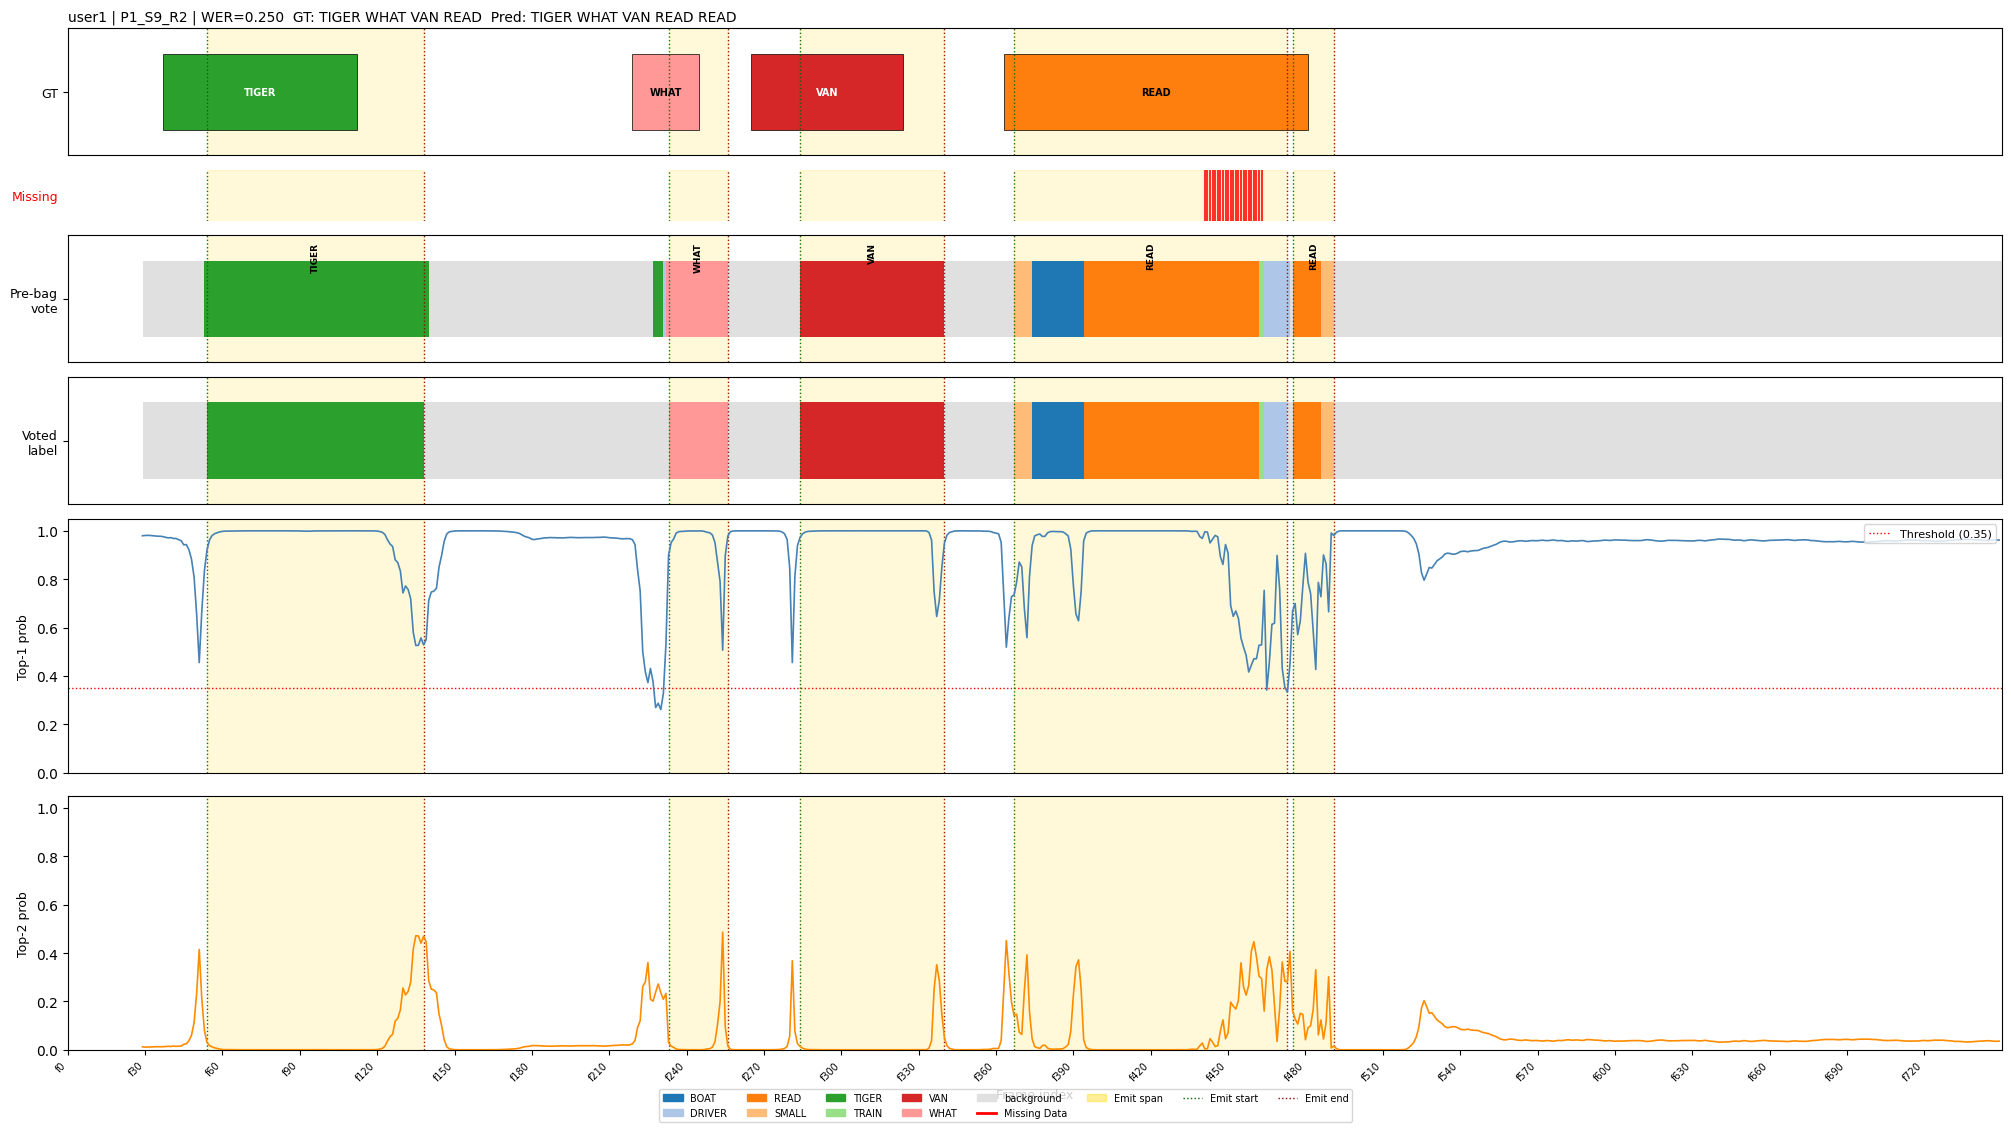

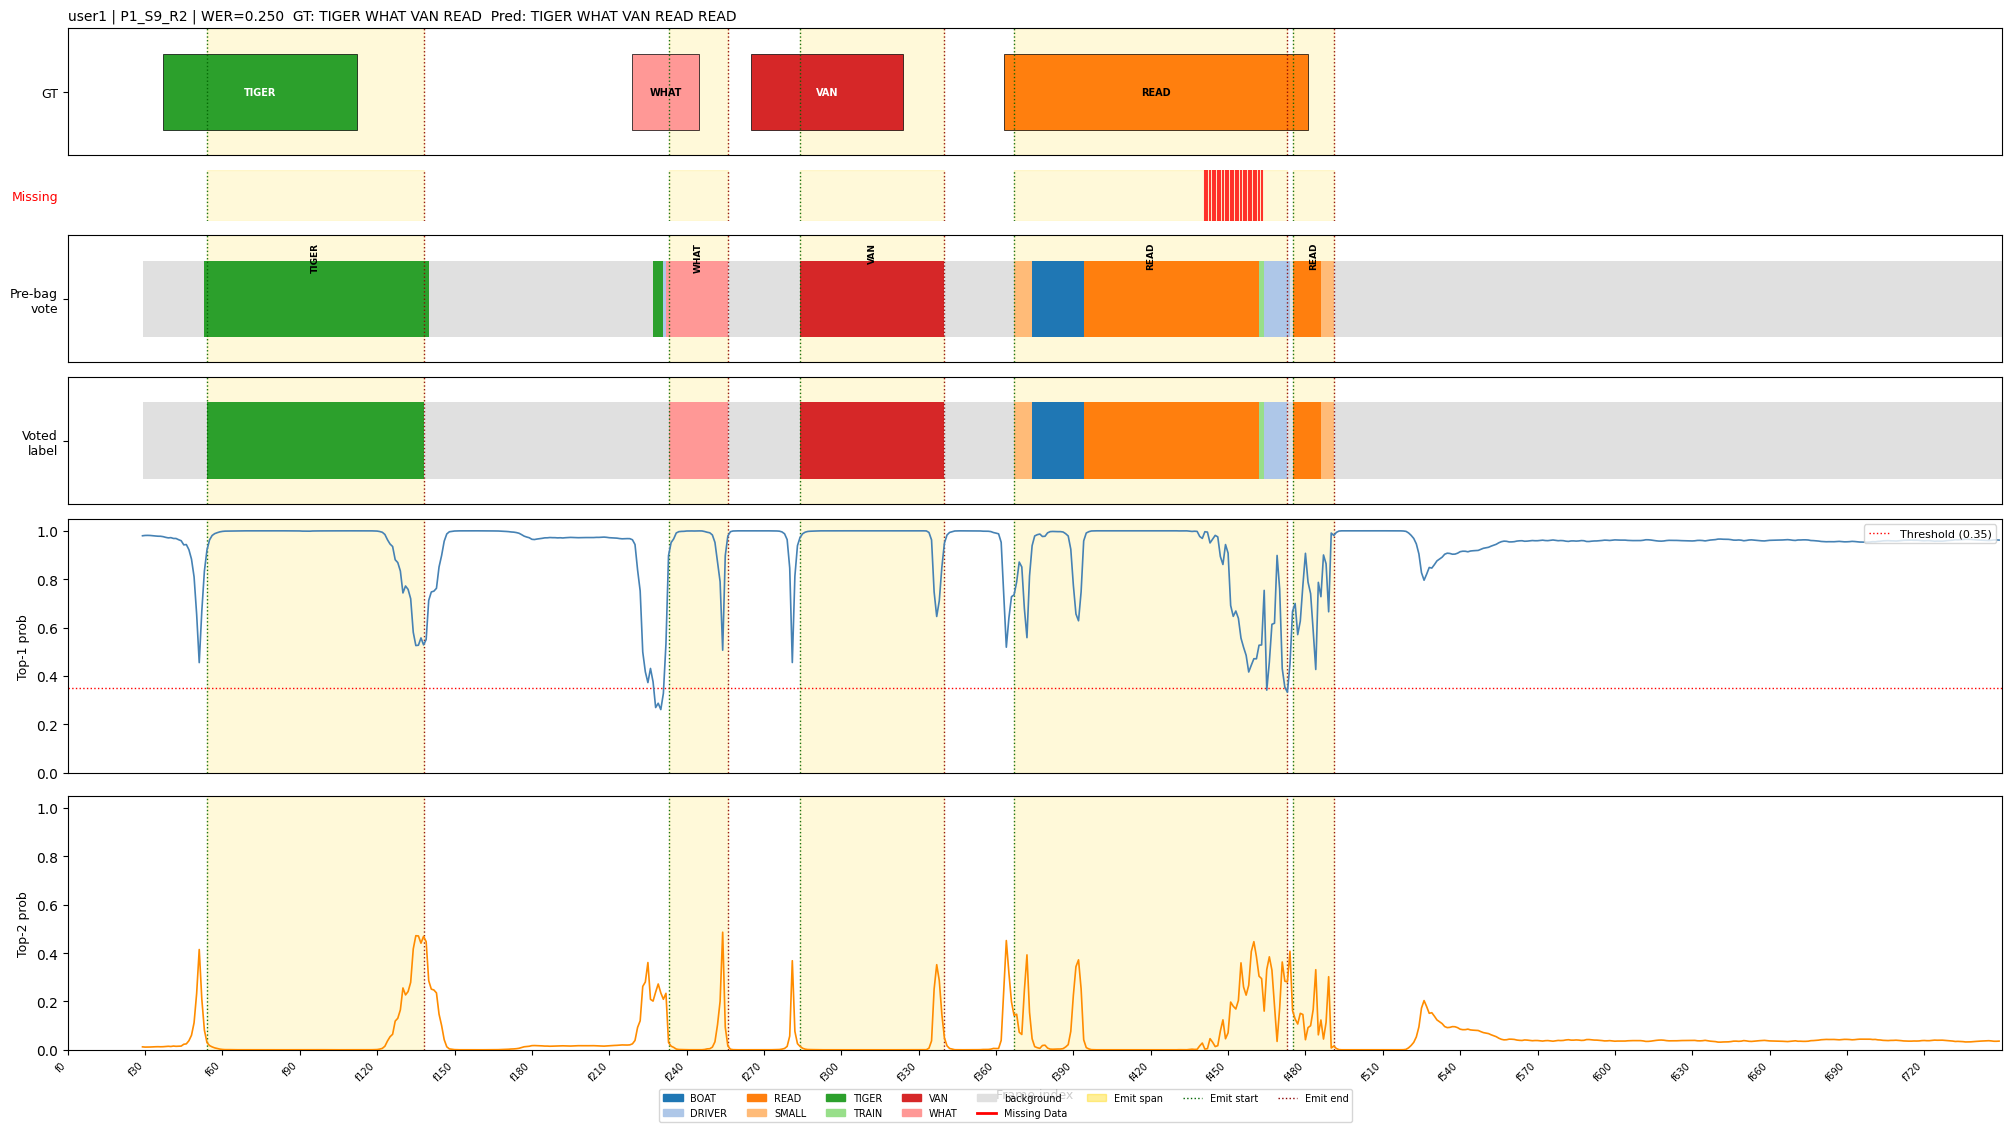

In [14]:
sequence_id = "P1_S9_R2"
user = "user1"
row = test_df.iloc[get_index(test_df, sequence_id)]

# Assuming the base dataset path. You might need to adjust this depending on the notebook's relative path
dataset_root = Path(f"c:/Shoab/Thesis/Experiments/dataset/")
user = row.get('user')  # Assuming this gets you "user1"
csv_path = dataset_root / user / "leap_data" / f"{sequence_id}.csv"

plot_sequence_timeline(row, test_arrays, csv_path=csv_path)

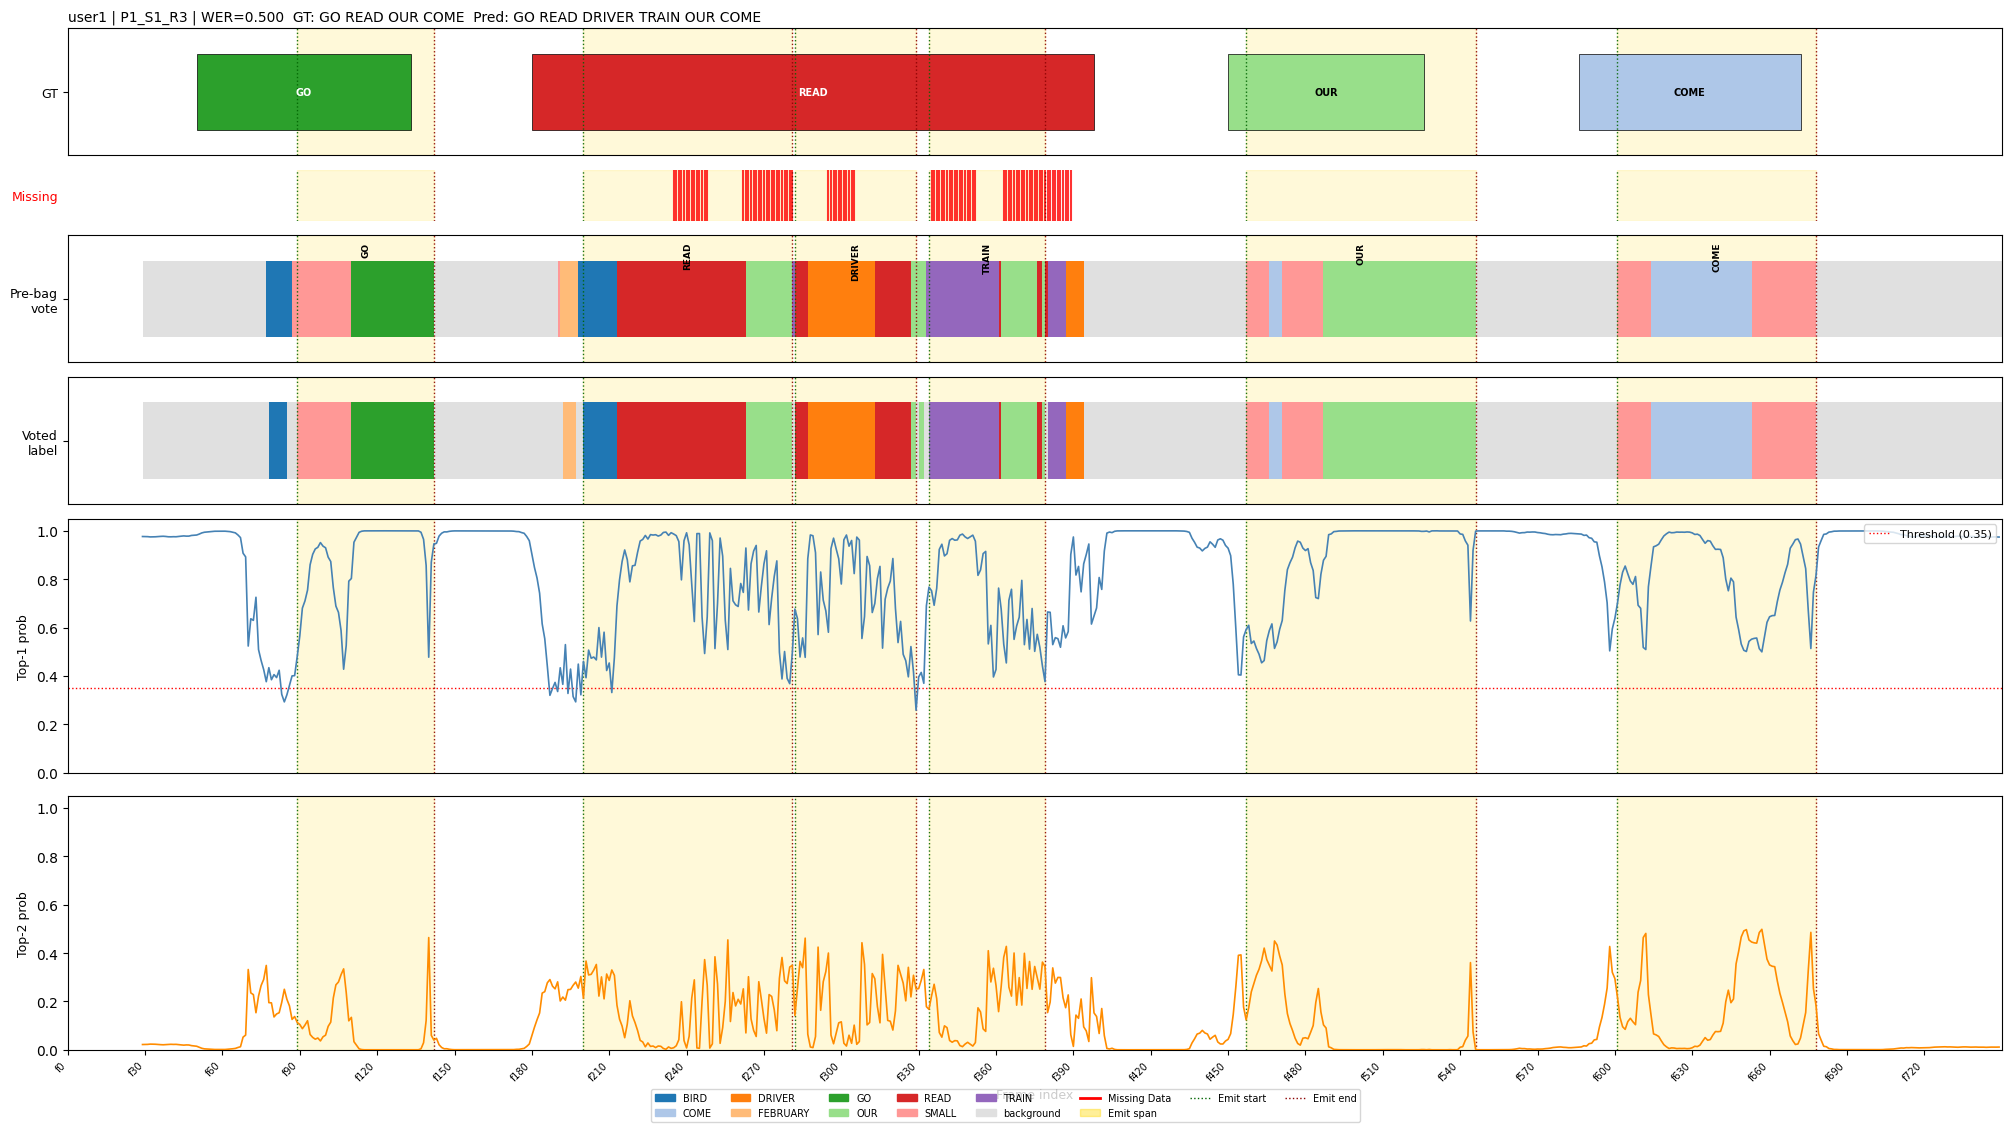

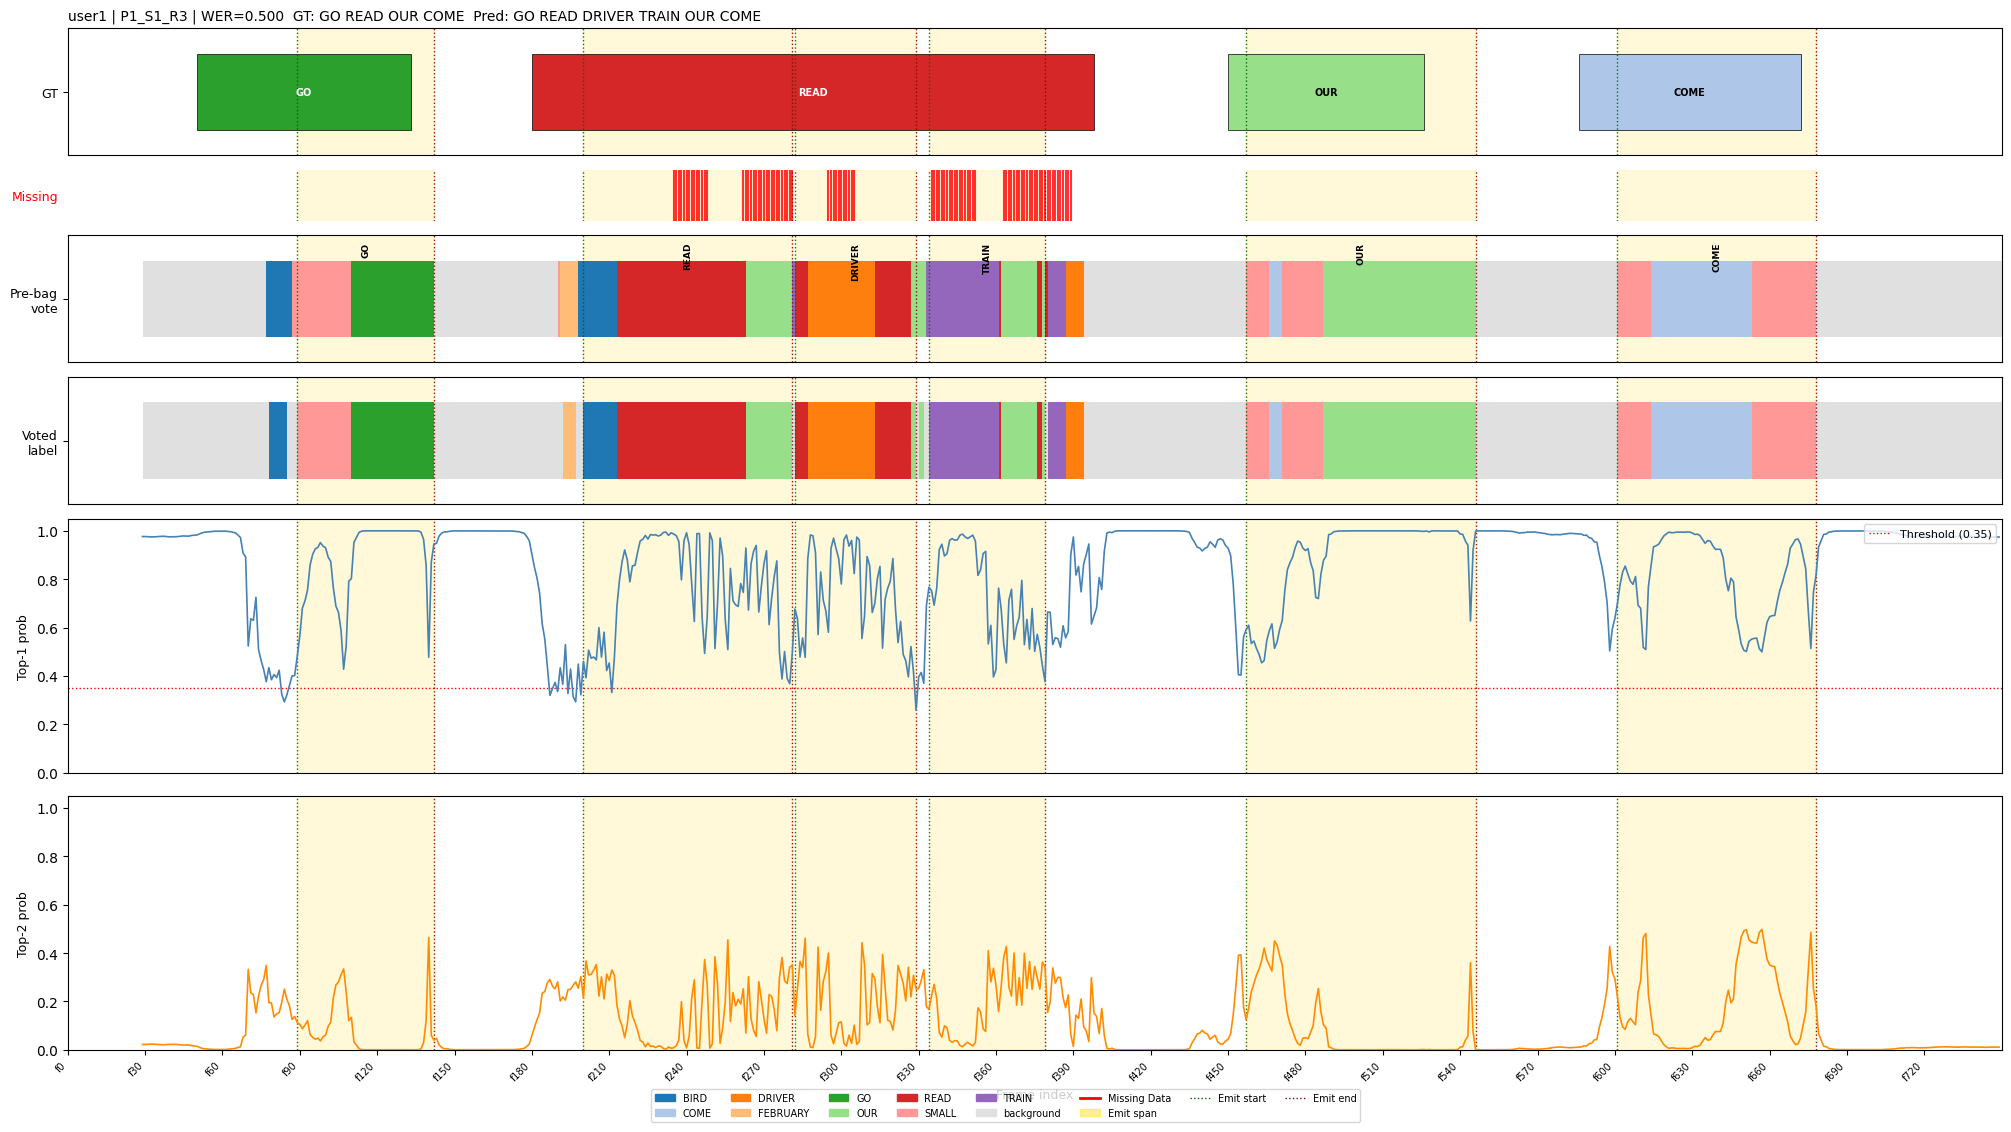

In [15]:
sequence_id = "P1_S1_R3"
user = "user1"
row = test_df.iloc[get_index(test_df, sequence_id)]

# Assuming the base dataset path. You might need to adjust this depending on the notebook's relative path
dataset_root = Path(f"c:/Shoab/Thesis/Experiments/dataset/")
user = row.get('user')  # Assuming this gets you "user1"
csv_path = dataset_root / user / "leap_data" / f"{sequence_id}.csv"

plot_sequence_timeline(row, test_arrays, csv_path=csv_path)

In [32]:
# ============================================================
# Plot 2 — Confidence heatmap for the first test sequence
# (requires id_to_label to be populated above)
# ============================================================
# if id_to_label:
#     plot_confidence_heatmap(row, test_arrays, id_to_label=id_to_label)
# else:
#     print("Skipped: populate id_to_label in the configuration cell first.")


  Top 5 worst sequences — Test
  #1   WER=0.500  user=user5
       id  : P5_S1_R6
       GT  : GO READ OUR COME
       pred: GO READ GO UGLY COME

  #2   WER=0.250  user=user5
       id  : P5_S8_R5
       GT  : BIG GREETINGS WHICH FARMING
       pred: BIG SMALL GREETINGS WHICH FARMING

  #3   WER=0.250  user=user5
       id  : P5_S5_R5
       GT  : BIRD WHAT DRIVER GREETINGS
       pred: BIRD WHAT DRIVER BIRD GREETINGS

  #4   WER=0.250  user=user5
       id  : P5_S2_R7
       GT  : FARMING BIG VAN SMALL
       pred: VAN BIG VAN SMALL

  #5   WER=0.250  user=user5
       id  : P5_S1_R5
       GT  : GO READ OUR COME
       pred: GO BOAT OUR COME




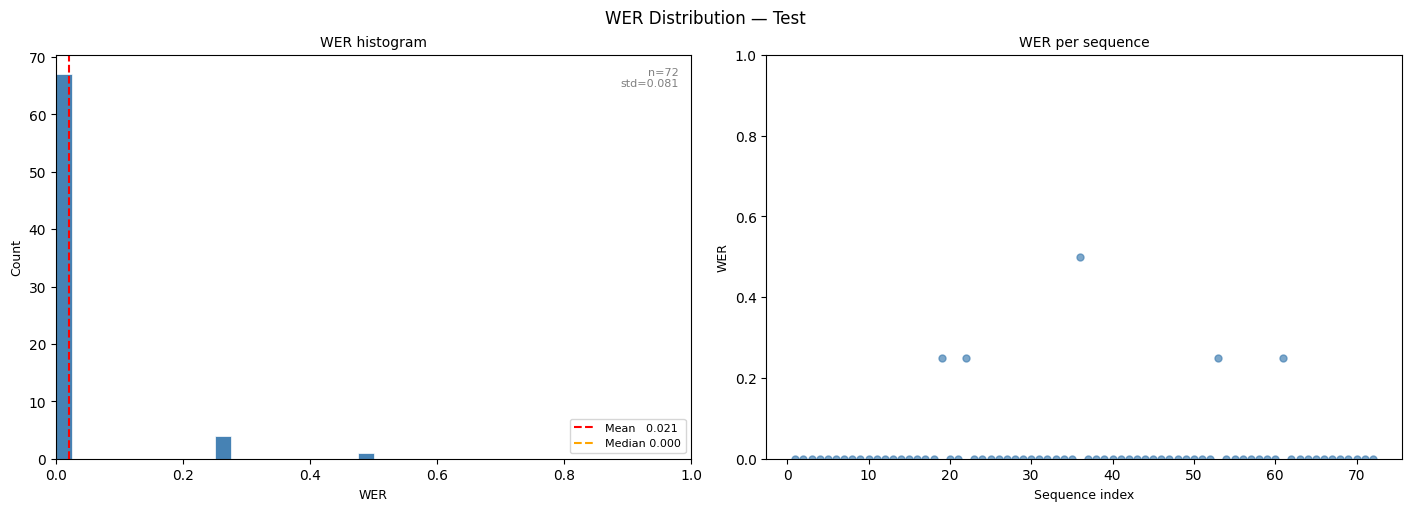

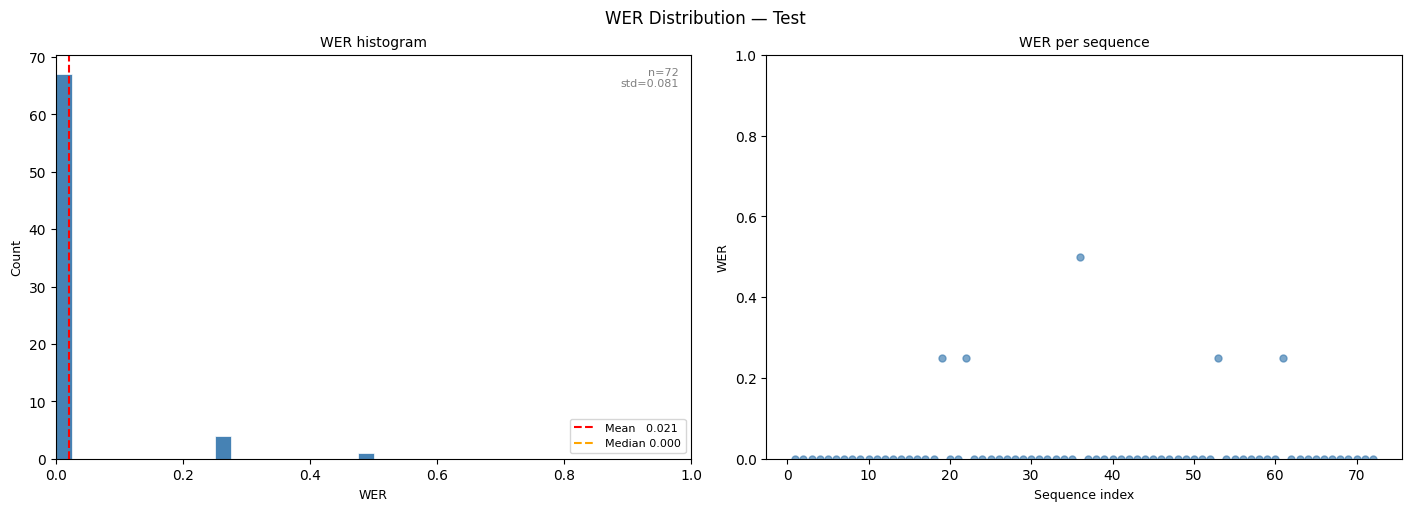

In [45]:
# ============================================================
# Plot 3 — WER distribution for the test split
# ============================================================
plot_wer_distribution(test_df, split_name="Test", top_n_worst=5)

C:\Users\User\AppData\Local\Temp\ipykernel_10468\3447845455.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(



  Top 5 worst sequences — Val
  #1   WER=0.000  user=user2
       id  : P2_S9_R6
       GT  : TIGER WHAT VAN READ
       pred: TIGER WHAT VAN READ

  #2   WER=0.000  user=user2
       id  : P2_S6_R6
       GT  : WHICH OUR TRAIN
       pred: WHICH OUR TRAIN

  #3   WER=0.000  user=user2
       id  : P2_S7_R1
       GT  : COME DRIVER BIRD
       pred: COME DRIVER BIRD

  #4   WER=0.000  user=user2
       id  : P2_S2_R1
       GT  : FARMING BIG VAN SMALL
       pred: FARMING BIG VAN SMALL

  #5   WER=0.000  user=user2
       id  : P2_S6_R4
       GT  : WHICH OUR TRAIN
       pred: WHICH OUR TRAIN




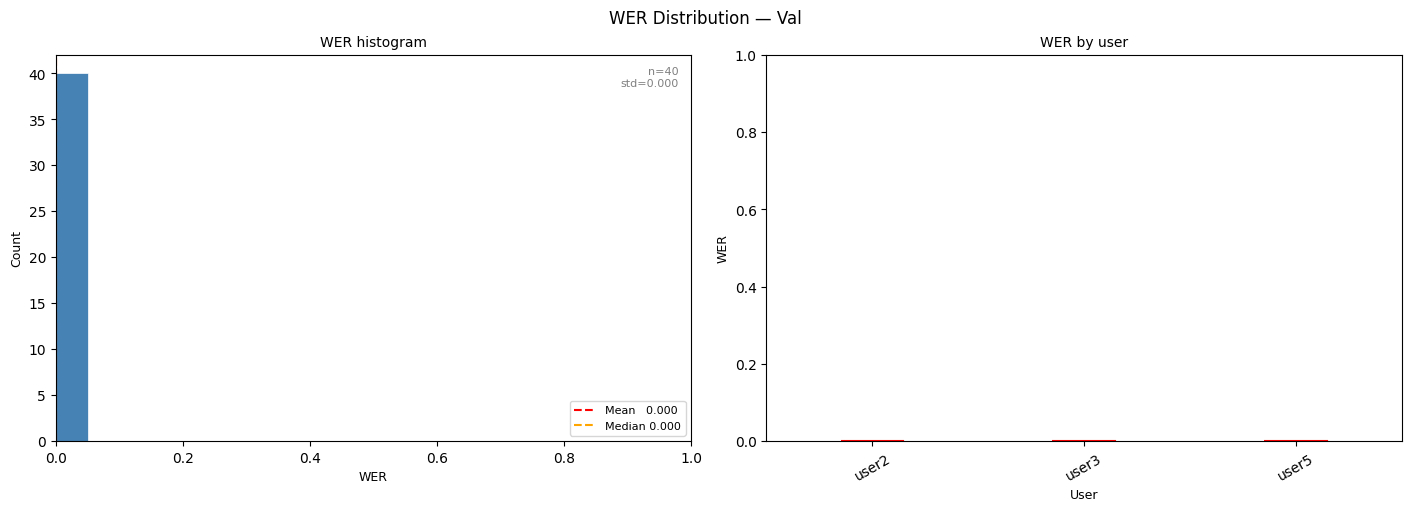

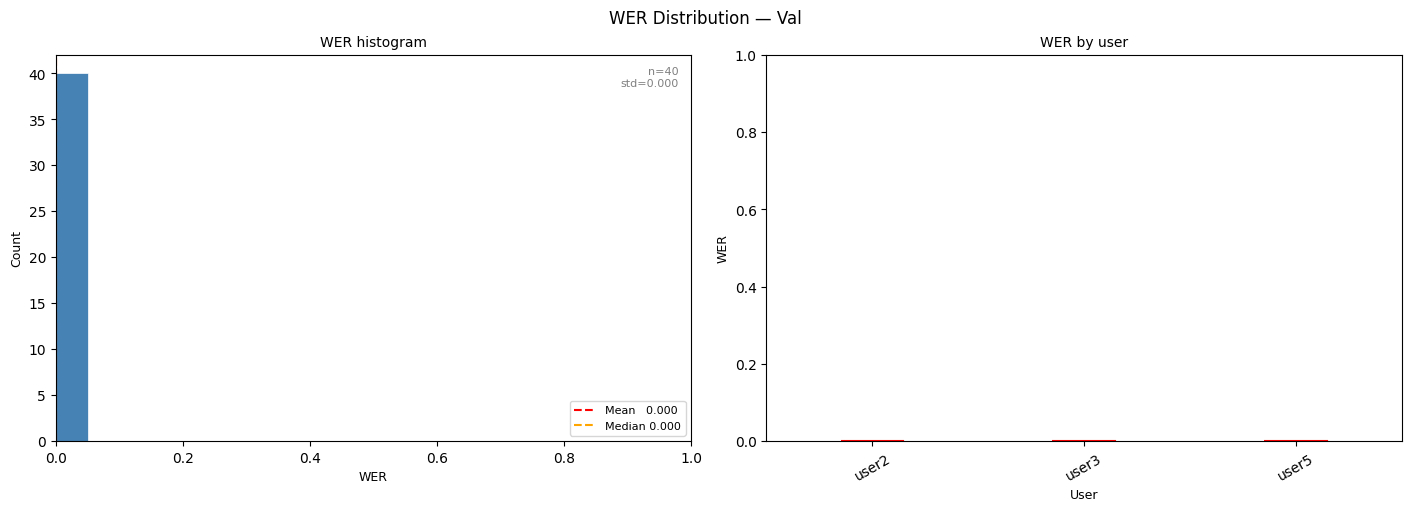

In [36]:
plot_wer_distribution(val_df, split_name="Val", top_n_worst=5)

In [22]:
# ============================================================
# Plot 4 — Split overview grid (first 20 sequences)
# ============================================================
# plot_split_overview(test_df, test_arrays, max_sequences=20)

In [23]:
# ============================================================
# Plot 5 — Sign-level confusion matrix
# ============================================================
# plot_confusion_from_emissions(test_df)

In [ ]:
# ============================================================
# (Optional) Batch export — timeline + heatmap for every sequence
# Uncomment and set output_dir before running.
# ============================================================

# plot_all_sequences(
#     test_df, test_arrays,
#     id_to_label=id_to_label,
#     output_dir="./plots/test",
#     include_heatmap=True,
# )

In [4]:
"""
shrec_metrics.py
================
SHREC'21 online gesture recognition metrics computed entirely from saved
inference results (parquet + npz).  No model or inference code required.

Typical usage
-------------
    from shrec_metrics import load_split_results, compute_shrec_from_saved

    df, arrays = load_split_results("test")
    summary    = compute_shrec_from_saved(
        df, arrays, id_to_label, split_name="Test (user_1)"
    )
    # summary["macro_detection_rate"], summary["macro_jaccard"], …

SHREC'21 metric definitions  (Caputo et al., Computers & Graphics 2021)
------------------------------------------------------------------------
  Detection Rate      = TP / (TP + FN)
  False Positive Rate = FP / (TP + FN)   [denominator = total GT gestures]
  Misclassification   = Misclassified / (TP + FN)
  Jaccard Index       = mean over classes of:
                          sum(overlap/union for matching same-class pairs)
                          / (jaccardCounts + Missed + Misclassified + FP)

Fixes vs. original MATLAB script (evaluateShrec21.m)
-----------------------------------------------------
FIX 1  Detection threshold  : overlap/GT_length > 0.5  (no +1 in overlap)
FIX 2  Loop structure       : outer=predictions, inner=GT; found[] on GT side
FIX 3  Misclassification    : tracked separately from False Positives
FIX 4  Jaccard              : interval-level, per matching same-class pair
FIX 5  Jaccard denominator  : jaccardCounts + Missed + Misclassified + FP
FIX 6  FPR / MR denominator : total GT gestures per class (TP + FN)
FIX 7  FP class attribution : predicted class (not the MATLAB bug)
"""

from __future__ import annotations

import json
import os

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Constants — override at call-site if your setup differs
# ---------------------------------------------------------------------------

RESULTS_DIR      = "./wer_results"
BACKGROUND_LABEL = "background"      # must match whatever was used at training time


# ===========================================================================
# Loading helpers  (copied verbatim from your saving/loading code)
# ===========================================================================

def load_split_results(
    split_name:  str,
    results_dir: str = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Reads two files written by save_split_results():
        {slug}_metadata.parquet  — WER scalars, GT glosses, predictions,
                                   emit_regions and gt_segments (as JSON strings)
        {slug}_arrays.npz        — per-frame logit/prob/label/state arrays

    Parameters
    ----------
    split_name  : e.g. "test", "dev_val", "test_(user1)" — must match
                  the slug used when saving
    results_dir : directory containing the parquet / npz files

    Returns
    -------
    df     : DataFrame with all scalars + list columns
    arrays : dict keyed by "{row_idx}__{rec_id}__{field}"
    """
    slug = (
        split_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    parquet_path = os.path.join(results_dir, f"{slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    def _deserialize_regions(x) -> list[tuple]:
        if not isinstance(x, str):
            return []
        out = []
        for r in json.loads(x):
            if isinstance(r, dict):
                out.append((int(r["start_frame"]), int(r["end_frame"]), str(r["label"])))
            elif isinstance(r, (list, tuple)) and len(r) >= 3:
                out.append((int(r[0]), int(r[1]), str(r[2])))
        return out

    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(_deserialize_regions)

    npz    = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(row: pd.Series, arrays: dict) -> dict:
    """
    Extract all per-frame arrays for a single DataFrame row.

    Returns
    -------
    dict with keys:
        pre_bag_logits  (T, C) float32  — raw model logits before bag pooling
        post_bag_probs  (T, C) float32  — softmax probs after bag; first
                                          (BAG_SIZE-1) rows are NaN
        frame_indices   (T,)   int32    — original frame numbers
        raw_labels      (T,)   object   — per-frame pre-bag top-1 label string
        voted_labels    (T,)   object   — post-bag majority-vote label string
        raw_conf        (T,)   float32  — pre-bag top-1 confidence
        bg_conf         (T,)   float32  — post-bag background class confidence
        states          (T,)   object   — decoder FSM state string per frame
    """
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {f: arrays.get(f"{prefix}__{f}") for f in fields}


def _safe_segment_tuple(seg) -> tuple[int, int, str] | None:
    """Convert a segment tuple/list/dict to (int start, int end, str label).
    Returns None if the input cannot be safely cast."""
    if isinstance(seg, dict):
        try:
            return (int(seg["start_frame"]), int(seg["end_frame"]), str(seg["label"]))
        except (KeyError, ValueError, TypeError):
            return None
    if isinstance(seg, (tuple, list)) and len(seg) >= 3:
        try:
            return (int(seg[0]), int(seg[1]), str(seg[2]))
        except (ValueError, TypeError):
            pass
    return None


# ===========================================================================
# SHREC'21 global accumulators
# ===========================================================================

_shrec_num_classes         = 0
_shrec_total_gestures      = None
_shrec_correct_predictions = None
_shrec_missed              = None
_shrec_misclassified       = None
_shrec_false_positives     = None
_shrec_latencies           = None
_shrec_jaccard_sum         = None
_shrec_jaccard_counts      = None


def shrec_initialize(n_gesture_classes: int) -> None:
    """
    Reset all SHREC'21 accumulators.

    Call once before iterating sequences, passing the number of gesture
    classes excluding background.
    """
    global _shrec_num_classes
    global _shrec_total_gestures, _shrec_correct_predictions
    global _shrec_missed, _shrec_misclassified, _shrec_false_positives
    global _shrec_latencies, _shrec_jaccard_sum, _shrec_jaccard_counts

    _shrec_num_classes         = int(n_gesture_classes)
    nc                         = _shrec_num_classes
    _shrec_total_gestures      = [0]   * nc
    _shrec_correct_predictions = [0]   * nc
    _shrec_missed              = [0]   * nc
    _shrec_misclassified       = [0]   * nc
    _shrec_false_positives     = [0]   * nc
    _shrec_latencies           = [[]   for _ in range(nc)]
    _shrec_jaccard_sum         = [0.0] * nc
    _shrec_jaccard_counts      = [0]   * nc


# ===========================================================================
# Internal helpers
# ===========================================================================

def _overlap_ratio(s_true: int, e_true: int,
                   s_pred: int, e_pred: int) -> float:
    """FIX 1 — overlap / GT_length, no +1."""
    overlap   = min(e_true, e_pred) - max(s_true, s_pred)
    gt_length = e_true - s_true
    return overlap / max(gt_length, 1)


def _majority_class(y_pred: list[int], s: int, e: int, n_classes: int) -> int | None:
    """
    Most frequent non-background class in y_pred[s : e+1].
    Both -1 and n_classes are treated as background.
    Returns None if every frame is background.
    """
    segment = [
        y_pred[i]
        for i in range(s, min(e + 1, len(y_pred)))
        if y_pred[i] not in (-1, n_classes)
    ]
    if not segment:
        return None
    return max(set(segment), key=segment.count)


def _build_pred_intervals(
    emit_regions:  list[tuple],
    frame_voted_preds: list[int],
    n_classes:     int,
    label_to_id:   dict[str, int],
) -> list[dict]:
    """
    Convert emit_regions [(start, end, label), ...] into metric-ready dicts.

    Class id is resolved via label_to_id first; falls back to majority vote
    over frame_voted_preds in [start, end] if the label is missing or OOB.
    Regions with a None end frame (incomplete flush) are skipped.
    """
    intervals = []
    for region in emit_regions:
        t = _safe_segment_tuple(region)
        if t is None or t[1] is None:
            continue
        s, e, lbl = t
        cid = label_to_id.get(lbl, -1)
        if cid < 0 or cid >= n_classes:
            cid = _majority_class(frame_voted_preds, s, e, n_classes)
        intervals.append({"start": s, "end": e, "class": cid})
    return intervals


# ===========================================================================
# Core metric loop  (mirrors MATLAB evaluateShrec21.m structure exactly)
# ===========================================================================

def _compute_metrics(
    gt_intervals:   list[tuple[int, int]],
    gt_classes:     list[int],
    pred_intervals: list[dict],
    frame_voted_preds: list[int],
    n_classes:      int,
) -> tuple:
    """
    One-pass metric computation for a single sequence.

    FIX 2  outer=predictions, inner=GT; found[] flag lives on GT side.
    FIX 3  misclassification is separate from FP.
    FIX 4  Jaccard accumulated per overlapping same-class pair.

    Returns
    -------
    (total_gestures, correct_predictions, missed, misclassified,
     false_positives, latencies, jaccard_sum, jaccard_counts)
    """
    total_gestures      = [0]   * n_classes
    correct_predictions = [0]   * n_classes
    missed              = [0]   * n_classes
    misclassified       = [0]   * n_classes
    false_positives     = [0]   * n_classes
    latencies           = [[]   for _ in range(n_classes)]
    jaccard_sum         = [0.0] * n_classes
    jaccard_counts      = [0]   * n_classes

    num_gt = len(gt_intervals)
    for i in range(num_gt):
        cls = int(gt_classes[i])
        if 0 <= cls < n_classes:
            total_gestures[cls] += 1

    found = [0] * num_gt   # GT-side flag — prevents double-counting a GT as TP

    for pred in pred_intervals:
        s_pred, e_pred, pred_cls = pred["start"], pred["end"], pred["class"]
        detected = False

        for i, (s_true, e_true) in enumerate(gt_intervals):
            true_class = int(gt_classes[i])
            if true_class < 0 or true_class >= n_classes:
                continue

            # FIX 4 — Jaccard: every overlapping same-class pair
            overlap = min(e_true, e_pred) - max(s_true, s_pred)
            if overlap > 0 and pred_cls == true_class:
                u = max(e_true, e_pred) - min(s_true, s_pred)
                if u > 0:
                    jaccard_sum[true_class]    += overlap / u
                    jaccard_counts[true_class] += 1

            # FIX 1 — detection threshold
            if _overlap_ratio(s_true, e_true, s_pred, e_pred) > 0.5:
                detected = True
                if pred_cls == true_class:
                    if found[i] == 0:           # count GT only once
                        found[i] = 1
                        correct_predictions[true_class] += 1
                        # Latency: first frame ≥ s_pred where model voted true_class
                        first_correct = s_pred
                        for f in range(s_pred, e_pred + 1):
                            if f < len(frame_voted_preds) and frame_voted_preds[f] == true_class:
                                first_correct = f
                                break
                        latencies[true_class].append(max(0, first_correct - s_true))
                else:
                    # FIX 3 — wrong label, overlaps GT → misclassification on GT class
                    misclassified[true_class] += 1

        # FIX 7 — FP attributed to predicted class
        if not detected and pred_cls is not None and 0 <= pred_cls < n_classes:
            false_positives[pred_cls] += 1

    # Missed: GT gestures never matched by any prediction
    for i in range(num_gt):
        if found[i] == 0:
            cls = int(gt_classes[i])
            if 0 <= cls < n_classes:
                missed[cls] += 1

    return (total_gestures, correct_predictions, missed,
            misclassified, false_positives, latencies,
            jaccard_sum, jaccard_counts)


# ===========================================================================
# Per-sequence accumulator  (called once per row)
# ===========================================================================

def _shrec_update_from_row(
    row:              pd.Series,
    arrays:           dict,
    id_to_label:      dict[int, str],
    background_label: str  = BACKGROUND_LABEL,
    verbose:          bool = False,
) -> None:
    """
    Reconstruct frame_voted_preds from saved arrays and accumulate
    SHREC'21 metrics for one sequence into the global counters.

    frame_voted_preds reconstruction
    ---------------------------------
    voted_labels is post-bag and stride-sparse: only frames where the
    decoder fired carry a label; all other positions remain -1.
    This is identical to what the online decoder stored, so latency
    numbers are consistent between the live and loaded paths.
    """
    global _shrec_total_gestures, _shrec_correct_predictions
    global _shrec_missed, _shrec_misclassified, _shrec_false_positives
    global _shrec_latencies, _shrec_jaccard_sum, _shrec_jaccard_counts

    nc          = _shrec_num_classes
    label_to_id = {v: k for k, v in id_to_label.items()}

    # ---- Reconstruct frame_voted_preds from npz ----------------------------
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    voted_labels  = arrays.get(f"{prefix}__voted_labels")   # (S,) object  S = stream steps
    frame_indices = arrays.get(f"{prefix}__frame_indices")  # (S,) int32

    T = int(row.get("num_frames", 0))
    frame_voted_preds = [-1] * T

    if voted_labels is not None and frame_indices is not None:
        for fi, vlbl in zip(frame_indices.tolist(), voted_labels.tolist()):
            if str(vlbl) == background_label:
                continue
            cid = label_to_id.get(str(vlbl), -1)
            if 0 <= int(fi) < T and 0 <= cid < nc:
                frame_voted_preds[int(fi)] = cid

    # ---- Parse GT segments from the DataFrame row --------------------------
    gt_intervals = []
    gt_classes   = []
    for seg in (row.get("gt_segments") or []):
        t = _safe_segment_tuple(seg)
        if t is None:
            continue
        s, e, lbl = t
        if lbl == background_label:
            continue
        cid = label_to_id.get(lbl, -1)
        if 0 <= cid < nc:
            gt_intervals.append((s, e))
            gt_classes.append(cid)

    # ---- Build predicted intervals from emit_regions -----------------------
    emit_regions   = row.get("emit_regions") or []
    pred_intervals = _build_pred_intervals(emit_regions, frame_voted_preds, nc, label_to_id)

    # ---- Compute and accumulate --------------------------------------------
    (total_gest, correct_pred, missed, misclassified,
     false_positives, latencies, jaccard_sum, jaccard_counts) = _compute_metrics(
        gt_intervals, gt_classes, pred_intervals, frame_voted_preds, nc,
    )

    for i in range(nc):
        _shrec_total_gestures[i]      += total_gest[i]
        _shrec_correct_predictions[i] += correct_pred[i]
        _shrec_missed[i]              += missed[i]
        _shrec_misclassified[i]       += misclassified[i]
        _shrec_false_positives[i]     += false_positives[i]
        _shrec_latencies[i].extend(latencies[i])
        _shrec_jaccard_sum[i]         += jaccard_sum[i]
        _shrec_jaccard_counts[i]      += jaccard_counts[i]

    if verbose:
        rec = row.get("recording_id", "")
        print(f"  [SHREC] {rec}")
        for i in range(nc):
            if total_gest[i] > 0 or false_positives[i] > 0:
                dr  = correct_pred[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                mr  = misclassified[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                fpr = false_positives[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                jd  = jaccard_counts[i] + missed[i] + misclassified[i] + false_positives[i]
                jac = jaccard_sum[i] / jd if jd > 0 else 0.0
                lat = sum(latencies[i]) / len(latencies[i]) if latencies[i] else float("nan")
                lbl = id_to_label.get(i, str(i))
                print(f"    Class {i} ({lbl}): DR={dr:.2f}  MR={mr:.2f}  "
                      f"FPR={fpr:.2f}  Latency={lat:.1f}fr  Jaccard={jac:.3f}")


# ===========================================================================
# Print global results
# ===========================================================================

def shrec_print_global_results(
    id_to_label:      dict[int, str] | None = None,
    background_label: str                   = BACKGROUND_LABEL,
    split_name:       str                   = "",
) -> dict:
    """
    Print per-class and macro-averaged SHREC'21 results.

    Returns
    -------
    dict — macro-averaged scalars:
        macro_detection_rate, macro_misclass_rate,
        macro_false_positive_rate, macro_jaccard
    """
    nc     = _shrec_num_classes
    header = f"SHREC'21 METRICS — {split_name}" if split_name else "SHREC'21 METRICS"

    print(f"\n{'=' * 62}")
    print(header)
    print(f"{'=' * 62}")
    print(f"  Gesture classes : {nc}")
    print(f"  FIX 1  detection threshold : overlap/GT_len > 0.5")
    print(f"  FIX 2  loop structure      : outer=pred, inner=GT")
    print(f"  FIX 3  misclassification   : separate from FP")
    print(f"  FIX 4  Jaccard             : interval-level, same-class pairs")
    print(f"  FIX 5  Jaccard denominator : counts+missed+misc+FP")
    print(f"  FIX 6  FPR/MR denominator  : total GT gestures per class")
    print(f"  FIX 7  FP attribution      : predicted class")
    print()

    per_class_rows = []
    all_dr, all_mr, all_fpr, all_jac = [], [], [], []
    total_tp = total_gt = total_fp = total_misc = 0

    for i in range(nc):
        gt   = _shrec_total_gestures[i]
        tp   = _shrec_correct_predictions[i]
        miss = _shrec_missed[i]
        misc = _shrec_misclassified[i]
        fp   = _shrec_false_positives[i]
        j_sum = _shrec_jaccard_sum[i]
        j_cnt = _shrec_jaccard_counts[i]

        if gt == 0 and fp == 0:
            continue

        name = (id_to_label.get(i, str(i)) if id_to_label else str(i))
        if name == background_label:
            continue

        dr  = tp   / gt if gt > 0 else 0.0
        mr  = misc / gt if gt > 0 else 0.0   # FIX 6
        fpr = fp   / gt if gt > 0 else 0.0   # FIX 6

        lat_list = _shrec_latencies[i]
        avg_lat  = sum(lat_list) / len(lat_list) if lat_list else float("nan")

        jac_denom = j_cnt + miss + misc + fp  # FIX 5
        avg_jac   = j_sum / jac_denom if jac_denom > 0 else 0.0

        print(f"  Class {i:>3d}  {name}")
        print(f"    GT: {gt}   TP: {tp}   Missed: {miss}   Misc: {misc}   FP: {fp}")
        print(f"    Detection Rate      : {dr:.4f}")
        print(f"    Misclass Rate       : {mr:.4f}")
        print(f"    False Positive Rate : {fpr:.4f}")
        print(f"    Avg Latency (frames): {avg_lat:.2f}")
        print(f"    Avg Jaccard         : {avg_jac:.4f}")
        print()

        per_class_rows.append({
            "class_id": i, "class_name": name,
            "gt": gt, "tp": tp, "missed": miss, "misc": misc, "fp": fp,
            "detection_rate": dr, "misclass_rate": mr,
            "false_positive_rate": fpr,
            "avg_latency_frames": avg_lat,
            "avg_jaccard": avg_jac,
        })

        total_tp   += tp;  total_gt   += gt
        total_fp   += fp;  total_misc += misc
        all_dr.append(dr); all_mr.append(mr)
        all_fpr.append(fpr); all_jac.append(avg_jac)

    macro_dr  = sum(all_dr)  / len(all_dr)  if all_dr  else float("nan")
    macro_mr  = sum(all_mr)  / len(all_mr)  if all_mr  else float("nan")
    macro_fpr = sum(all_fpr) / len(all_fpr) if all_fpr else float("nan")
    macro_jac = sum(all_jac) / len(all_jac) if all_jac else float("nan")

    print(f"{'─' * 62}")
    print("  MACRO AVERAGES (across gesture classes):")
    print(f"    Detection Rate      : {macro_dr:.4f}")
    print(f"    Misclass Rate       : {macro_mr:.4f}")
    print(f"    False Positive Rate : {macro_fpr:.4f}")
    print(f"    Jaccard Index       : {macro_jac:.4f}")
    print(f"{'=' * 62}\n")

    if per_class_rows:
        try:
            display(pd.DataFrame(per_class_rows).set_index("class_id"))
        except NameError:
            pass    # display() only available in notebooks

    return {
        "macro_detection_rate":      macro_dr,
        "macro_misclass_rate":       macro_mr,
        "macro_false_positive_rate": macro_fpr,
        "macro_jaccard":             macro_jac,
    }


# ===========================================================================
# Main entry point
# ===========================================================================

def compute_shrec_from_saved(
    df:               pd.DataFrame,
    arrays:           dict,
    id_to_label:      dict[int, str],
    split_name:       str  = "",
    background_label: str  = BACKGROUND_LABEL,
    verbose_per_seq:  bool = False,
) -> dict:
    """
    Compute SHREC'21 metrics for an entire split from saved files.

    Parameters
    ----------
    df               : DataFrame from load_split_results() — needs columns
                       emit_regions, gt_segments, recording_id, num_frames
    arrays           : arrays dict from load_split_results()
    id_to_label      : {int_id: label_string}
    split_name       : label shown in the printed results header
    background_label : label string for background class
    verbose_per_seq  : print per-sequence breakdown (useful for debugging)

    Returns
    -------
    dict — macro-averaged scalars:
        macro_detection_rate, macro_misclass_rate,
        macro_false_positive_rate, macro_jaccard

    Example
    -------
        df, arrays = load_split_results("test")
        summary    = compute_shrec_from_saved(
            df, arrays, id_to_label, split_name="Test (user_1)"
        )
    """
    n_gesture_classes = sum(1 for v in id_to_label.values() if v != background_label)
    shrec_initialize(n_gesture_classes)

    for _, row in df.iterrows():
        _shrec_update_from_row(
            row              = row,
            arrays           = arrays,
            id_to_label      = id_to_label,
            background_label = background_label,
            verbose          = verbose_per_seq,
        )

    return shrec_print_global_results(
        id_to_label      = id_to_label,
        background_label = background_label,
        split_name       = split_name,
    )

In [ ]:


# ── Test split ──────────────────────────────────────────────────────────────
test_df, test_arrays = load_split_results(
    split_name=f"test_user3",
    results_dir="./",
)

test_shrec = compute_shrec_from_saved(
    df               = test_df,
    arrays           = test_arrays,
    id_to_label      = id_to_label,
    split_name       = f"test_user5",
    background_label = BACKGROUND_LABEL,
    verbose_per_seq  = False,   # set True to see per-sequence breakdown
)

# ── Dev val split ────────────────────────────────────────────────────────────
val_df, val_arrays = load_split_results(
    split_name="val_user3",
    results_dir="./",
)

val_shrec = compute_shrec_from_saved(
    df               = val_df,
    arrays           = val_arrays,
    id_to_label      = id_to_label,
    split_name       = "val_user5",
    background_label = BACKGROUND_LABEL,
    verbose_per_seq  = False,
)

# ── Combined summary table ────────────────────────────────────────────────────
shrec_comparison_df = pd.DataFrame([
    {"split": f"test_user1", **test_shrec},
    {"split": "val_user1",             **val_shrec},
])

print("\n========== SHREC'21 SUMMARY TABLE ==========")
display(shrec_comparison_df)


SHREC'21 METRICS — test_user5
  Gesture classes : 20
  FIX 1  detection threshold : overlap/GT_len > 0.5
  FIX 2  loop structure      : outer=pred, inner=GT
  FIX 3  misclassification   : separate from FP
  FIX 4  Jaccard             : interval-level, same-class pairs
  FIX 5  Jaccard denominator : counts+missed+misc+FP
  FIX 6  FPR/MR denominator  : total GT gestures per class
  FIX 7  FP attribution      : predicted class

  Class   0  AUGUST
    GT: 10   TP: 10   Missed: 0   Misc: 0   FP: 0
    Detection Rate      : 1.0000
    Misclass Rate       : 0.0000
    False Positive Rate : 0.0000
    Avg Latency (frames): 12.70
    Avg Jaccard         : 0.7714

  Class   1  BIG
    GT: 12   TP: 12   Missed: 0   Misc: 0   FP: 0
    Detection Rate      : 1.0000
    Misclass Rate       : 0.0000
    False Positive Rate : 0.0000
    Avg Latency (frames): 8.42
    Avg Jaccard         : 0.7203

  Class   2  BIRD
    GT: 10   TP: 10   Missed: 0   Misc: 0   FP: 0
    Detection Rate      : 1.0000
   

,class_name,gt,tp,missed,misc,fp,detection_rate,misclass_rate,false_positive_rate,avg_latency_frames,avg_jaccard
class_id,,,,,,,,,,,
0,AUGUST,10,10,0,0,0,1.0,0.0,0.000,12.700000,0.771448
1,BIG,12,12,0,0,0,1.0,0.0,0.000,8.416667,0.720323
2,BIRD,10,10,0,0,0,1.0,0.0,0.000,24.700000,0.589041
3,BOAT,10,6,4,3,2,0.6,0.3,0.200,24.500000,0.291231
4,COME,10,10,0,0,0,1.0,0.0,0.000,18.700000,0.554949
5,DRIVER,10,10,0,0,0,1.0,0.0,0.000,20.300000,0.753234
6,FARMING,12,12,0,0,0,1.0,0.0,0.000,27.666667,0.594566
7,FEBRUARY,10,10,0,0,0,1.0,0.0,0.000,22.300000,0.719134
8,GO,10,10,0,0,0,1.0,0.0,0.000,14.200000,0.467327



SHREC'21 METRICS — val_user5
  Gesture classes : 20
  FIX 1  detection threshold : overlap/GT_len > 0.5
  FIX 2  loop structure      : outer=pred, inner=GT
  FIX 3  misclassification   : separate from FP
  FIX 4  Jaccard             : interval-level, same-class pairs
  FIX 5  Jaccard denominator : counts+missed+misc+FP
  FIX 6  FPR/MR denominator  : total GT gestures per class
  FIX 7  FP attribution      : predicted class

  Class   0  AUGUST
    GT: 10   TP: 10   Missed: 0   Misc: 0   FP: 0
    Detection Rate      : 1.0000
    Misclass Rate       : 0.0000
    False Positive Rate : 0.0000
    Avg Latency (frames): 11.30
    Avg Jaccard         : 0.7845

  Class   1  BIG
    GT: 8   TP: 8   Missed: 0   Misc: 0   FP: 0
    Detection Rate      : 1.0000
    Misclass Rate       : 0.0000
    False Positive Rate : 0.0000
    Avg Latency (frames): 10.50
    Avg Jaccard         : 0.6088

  Class   2  BIRD
    GT: 10   TP: 10   Missed: 0   Misc: 0   FP: 0
    Detection Rate      : 1.0000
    M

,class_name,gt,tp,missed,misc,fp,detection_rate,misclass_rate,false_positive_rate,avg_latency_frames,avg_jaccard
class_id,,,,,,,,,,,
0,AUGUST,10,10,0,0,0,1.000000,0.0,0.000000,11.300000,0.784529
1,BIG,8,8,0,0,0,1.000000,0.0,0.000000,10.500000,0.608768
2,BIRD,10,10,0,0,0,1.000000,0.0,0.000000,18.000000,0.684072
3,BOAT,7,7,0,0,0,1.000000,0.0,0.000000,17.000000,0.615847
4,COME,12,12,0,0,0,1.000000,0.0,0.000000,16.416667,0.574246
5,DRIVER,10,10,0,0,0,1.000000,0.0,0.000000,17.600000,0.775881
6,FARMING,8,7,1,0,1,0.875000,0.0,0.125000,12.428571,0.480398
7,FEBRUARY,7,7,0,0,0,1.000000,0.0,0.000000,19.714286,0.758258
8,GO,10,10,0,0,0,1.000000,0.0,0.000000,18.700000,0.607710



========== SHREC'21 SUMMARY TABLE ==========


,split,macro_detection_rate,macro_misclass_rate,macro_false_positive_rate,macro_jaccard
0,test_user3,0.940000,0.015,0.053750,0.580393
1,val_user3,0.953988,0.000,0.067679,0.586231
